# Data Importer

This document will be used to create a final table that can be used in the SLR to gather all the relevant informatioon that can be used for the SLR.

**All CSV (before final corpus)**

In [4]:
import pandas as pd

# robust auto-delimiter read; falls back to skipping malformed rows for a preview
try:
    df_combined = pd.read_csv("final.csv", sep=None, engine="python")
except pd.errors.ParserError:
    df_combined = pd.read_csv("final.csv", sep=None, engine="python", on_bad_lines="skip")

df_combined.head()

,﻿Key,Item Type,Publication Year,Author,Title_zotero,Publication Title,ISBN,ISSN,DOI,Url,...,Title_overleaf,Ref,Search,ML Technique(s),XAI Technique(s),Field,Novelty / Application,Limitations (if mentioned),Future Directions (if any),Year
0,FSNAUWL4,journalArticle,2022,"Park, H.J.; Kim, Y.; Kim, H.Y.",Stock market forecasting using a multi-task ap...,Applied Soft Computing,NaN,15684946 (ISSN),10.1016/j.asoc.2021.108106,https://www.scopus.com/inward/record.uri?eid=2...,...,Stock market forecasting using a multi-task ap...,\cite{park_stock_2022},Financial,"Long Short-Term Memory (LSTM), Random Forest (...",Feature Importance,Finance,Application,Model is explainable because it uses the varia...,NaN,2022.0
1,PEP8W9NM,journalArticle,2024,"Giudici, P.; Piergallini, A.; Recchioni, M.C.;...",Explainable Artificial Intelligence methods fo...,Physica A: Statistical Mechanics and its Appli...,NaN,03784371 (ISSN),10.1016/j.physa.2024.130176,https://www.scopus.com/inward/record.uri?eid=2...,...,Explainable Artificial Intelligence methods fo...,\cite{giudici_explainable_2024},Financial,"Long Short-Term Memory (LSTM), Gated Recurrent...",Shapley-Lorenz,Finance,Application,NaN,Future research should include the extension o...,2024.0
2,K9F6RCFG,journalArticle,2024,"Parente, M.; Rizzuti, L.; Trerotola, M.",A profitable trading algorithm for cryptocurre...,Expert Systems with Applications,NaN,09574174 (ISSN),10.1016/j.eswa.2023.121806,https://www.scopus.com/inward/record.uri?eid=2...,...,A profitable trading algorithm for cryptocurre...,\cite{parente_profitable_2024},Financial,Multi-Layer Perceptron (MLP),SHAP,Finance,Application,NaN,It is worthwhile to subject the trading system...,2024.0
3,MT3KUHCR,conferencePaper,2023,"Valensky, D.; Mohaghegh, M.",Evaluating Transparency: A Cross-Model Explora...,Proc. IEEE Asia-Pacific Conf. Comput. Sci. Dat...,979-835034107-2 (ISBN),NaN,10.1109/CSDE59766.2023.10487732,https://www.scopus.com/inward/record.uri?eid=2...,...,Evaluating Transparency: A Cross-Model Explora...,\cite{valensky_evaluating_2023},Financial,"Long Short-Term Memory (LSTM), Convolutional N...","SHAP, LIME, Feature Importance: Permutation Im...",Finance,Application,The LSTM and CNN models used were relatively s...,Adapt XAI methods to deep learning models that...,2023.0
4,ICEM7JC2,journalArticle,2024,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....",Deep Learning in Finance: A Survey of Applicat...,AI (Switzerland),NaN,26732688 (ISSN),10.3390/ai5040101,https://www.scopus.com/inward/record.uri?eid=2...,...,Deep Learning in Finance: A Survey of Applicat...,\cite{mienye_deep_2024},Financial,"Convolutional Neural Network (CNN), Long Short...","SHAP, LIME",NaN,Application,The complexity of models still limits their de...,"As models evolve and become more complex, ther...",2024.0


In [5]:
df_combined["Field"] = (
    df_combined["Field"]
    .astype(str)
    .str.replace(r"\s*\(.*?\)", "", regex=True)
    .str.strip()
)

# Create Insights in Data

### About the ML and XAI Methods

### **Create Insights for ML**

In [9]:
import pandas as pd

df_ml = df_combined.copy()

# Add Domain as a copy of Field (only if Domain does not already exist)
if "Domain" not in df_ml.columns:
    df_ml["Domain"] = df_ml["Field"]

# Add new manual columns only if missing
if "Specific Domain (Finance only)" not in df_ml.columns:
    df_ml["Specific Domain (Finance only)"] = ""

if "ML Techniques (Abbreviation)" not in df_ml.columns:
    df_ml["ML Techniques (Abbreviation)"] = ""

# Optional: trim whitespace in the added string columns
for c in ["Domain", "Specific Domain (Finance only)", "ML Techniques (Abbreviation)"]:
    df_ml[c] = df_ml[c].astype("string").str.strip()


In [10]:
df_ml.head()

,﻿Key,Item Type,Publication Year,Author,Title_zotero,Publication Title,ISBN,ISSN,DOI,Url,...,ML Technique(s),XAI Technique(s),Field,Novelty / Application,Limitations (if mentioned),Future Directions (if any),Year,Domain,Specific Domain (Finance only),ML Techniques (Abbreviation)
0,FSNAUWL4,journalArticle,2022,"Park, H.J.; Kim, Y.; Kim, H.Y.",Stock market forecasting using a multi-task ap...,Applied Soft Computing,NaN,15684946 (ISSN),10.1016/j.asoc.2021.108106,https://www.scopus.com/inward/record.uri?eid=2...,...,"Long Short-Term Memory (LSTM), Random Forest (...",Feature Importance,Finance,Application,Model is explainable because it uses the varia...,NaN,2022.0,Finance,,
1,PEP8W9NM,journalArticle,2024,"Giudici, P.; Piergallini, A.; Recchioni, M.C.;...",Explainable Artificial Intelligence methods fo...,Physica A: Statistical Mechanics and its Appli...,NaN,03784371 (ISSN),10.1016/j.physa.2024.130176,https://www.scopus.com/inward/record.uri?eid=2...,...,"Long Short-Term Memory (LSTM), Gated Recurrent...",Shapley-Lorenz,Finance,Application,NaN,Future research should include the extension o...,2024.0,Finance,,
2,K9F6RCFG,journalArticle,2024,"Parente, M.; Rizzuti, L.; Trerotola, M.",A profitable trading algorithm for cryptocurre...,Expert Systems with Applications,NaN,09574174 (ISSN),10.1016/j.eswa.2023.121806,https://www.scopus.com/inward/record.uri?eid=2...,...,Multi-Layer Perceptron (MLP),SHAP,Finance,Application,NaN,It is worthwhile to subject the trading system...,2024.0,Finance,,
3,MT3KUHCR,conferencePaper,2023,"Valensky, D.; Mohaghegh, M.",Evaluating Transparency: A Cross-Model Explora...,Proc. IEEE Asia-Pacific Conf. Comput. Sci. Dat...,979-835034107-2 (ISBN),NaN,10.1109/CSDE59766.2023.10487732,https://www.scopus.com/inward/record.uri?eid=2...,...,"Long Short-Term Memory (LSTM), Convolutional N...","SHAP, LIME, Feature Importance: Permutation Im...",Finance,Application,The LSTM and CNN models used were relatively s...,Adapt XAI methods to deep learning models that...,2023.0,Finance,,
4,ICEM7JC2,journalArticle,2024,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D....",Deep Learning in Finance: A Survey of Applicat...,AI (Switzerland),NaN,26732688 (ISSN),10.3390/ai5040101,https://www.scopus.com/inward/record.uri?eid=2...,...,"Convolutional Neural Network (CNN), Long Short...","SHAP, LIME",nan,Application,The complexity of models still limits their de...,"As models evolve and become more complex, ther...",2024.0,nan,,


In [11]:
# Finance subdomain classification based solely on Domain (LLM) - this will be manually checked as described in paper
import re, time, requests
import pandas as pd
from typing import Optional

# Config: reuse existing globals if present
MODEL_NAME = globals().get("MODEL_NAME", "llama3.1:8b")
GEN_URL    = globals().get("GEN_URL", "http://127.0.0.1:11434/api/generate")

# Canonical finance subdomains
FINANCE_SUBDOMAINS = [
    "Portfolio Optimization", "Asset Allocation", "Algorithmic Trading", "High-Frequency Trading",
    "Risk Management", "Credit Risk", "Asset Pricing", "Factor Models",
    "Derivatives / Option Pricing", "Fixed Income", "Volatility Modeling", "Market Microstructure",
    "Financial Forecasting", "Corporate Finance", "Behavioral Finance", "Financial Econometrics",
    "Stress Testing / VaR", "Cryptocurrency / Blockchain", "Insurance / Actuarial", "Other (Finance)"
]
_LUT = {s.lower(): s for s in FINANCE_SUBDOMAINS}

def infer_finance_subdomain_llm(abstract: Optional[str]) -> Optional[str]:
    """Ask the local LLM (Ollama) for exactly one finance subdomain."""
    if not isinstance(abstract, str) or not abstract.strip():
        return None
    prompt = f"""You are a precise classifier for FINANCE research abstracts.
Choose EXACTLY one label from this list and output ONLY the label text:

{', '.join(FINANCE_SUBDOMAINS)}

If nothing fits, output: Other (Finance).

Abstract:
\"\"\"{abstract.strip()[:5000]}\"\"\""""
    try:
        r = requests.post(
            GEN_URL,
            json={"model": MODEL_NAME, "prompt": prompt, "stream": False, "options": {"temperature": 0}},
            timeout=60
        )
        r.raise_for_status()
        text = (r.json().get("response") or "").strip()
        label = text.splitlines()[0].strip().strip(":.- ")
        return _LUT.get(label.lower(), label)
    except Exception:
        return None

# Lightweight keyword fallback if LLM is unavailable
HEURISTICS = [
    ("High-Frequency Trading", r"\bhft\b|high[- ]frequency|microsecond|millisecond|latenc"),
    ("Algorithmic Trading", r"\balgorithmic trad|trading strategy|backtest|execution algo|market making"),
    ("Portfolio Optimization", r"\bportfolio optim|mean[- ]variance|efficient frontier|rebalanc|transaction cost"),
    ("Asset Allocation", r"\basset allocation|strategic|tactical|long[- ]only|multi[- ]asset"),
    ("Risk Management", r"\brisk manag|risk control|downside risk|expected shortfall|var\b|value[- ]at[- ]risk"),
    ("Credit Risk", r"\bcredit risk|default|pd\b|probability of default|lgd\b|loss given default"),
    ("Derivatives / Option Pricing", r"\boption pricing|black[- ]scholes|implied volatil|greeks|derivative"),
    ("Fixed Income", r"\byield curve|term structure|bond|treasury|duration|convexity"),
    ("Volatility Modeling", r"\bgarch|egarch|heston|stochastic volatil|volatility model"),
    ("Asset Pricing", r"\basset pricing|pricing kernel|consumption[- ]based|capm|icappm"),
    ("Factor Models", r"\bfactor model|fama[- ]french|momentum|value factor|size factor|risk premia"),
    ("Market Microstructure", r"\bmicrostructure|order book|limit order|tick size|bid[- ]ask spread"),
    ("Financial Forecasting", r"\bforecast|prediction|nowcast|time series|lstm|gru|transformer"),
    ("Corporate Finance", r"\bcorporate finance|capital structure|dividend|m&a|merger|acquisition"),
    ("Behavioral Finance", r"\bbehavioral finance|investor sentiment|anomal"),
    ("Financial Econometrics", r"\beconometric|panel data|cointegration|arima|var\b(?!\s*model)"),
    ("Stress Testing / VaR", r"\bstress test|scenario analysis|value[- ]at[- ]risk|var\b"),
    ("Cryptocurrency / Blockchain", r"\bcrypto(currency)?|blockchain|bitcoin|ethereum|defi"),
    ("Insurance / Actuarial", r"\bactuar|insurance|premium|claims|solvency"),
]
def infer_finance_subdomain_fallback(abstract: Optional[str]) -> Optional[str]:
    if not isinstance(abstract, str) or not abstract.strip():
        return None
    txt = abstract.lower()
    for label, pattern in HEURISTICS:
        if re.search(pattern, txt):
            return label
    return "Other (Finance)"

# Cached classifier
_cache_fin: dict[str, str] = {}
def classify_finance_subdomain(abstract: Optional[str]) -> Optional[str]:
    key = (abstract or "").strip()
    if not key:
        return None
    if key in _cache_fin:
        return _cache_fin[key]
    label = infer_finance_subdomain_llm(key) or infer_finance_subdomain_fallback(key)
    _cache_fin[key] = label
    time.sleep(0.02)  # gentle pacing if LLM is live
    return label

# --- Apply only where Domain (LLM) == "Finance" ---
if "Domain" not in df_ml.columns:
    raise KeyError("df_ml must contain 'Domain'.")
if "Abstract Note" not in df_ml.columns:
    raise KeyError("df_ml must contain 'Abstract Note'.")

target_col = "Specific Domain (Finance only)"
if target_col not in df_ml.columns:
    df_ml[target_col] = ""

mask_fin = df_ml["Domain"].astype("string").str.strip().str.casefold().eq("finance")

# classify Finance rows; blank out others
df_ml.loc[mask_fin, target_col] = (
    df_ml.loc[mask_fin, "Abstract Note"]
         .apply(classify_finance_subdomain)
         .astype("string").str.strip()
)
df_ml.loc[~mask_fin, target_col] = ""

In [12]:
import re
import pandas as pd

# Create some helpers
_ABBR_RE = re.compile(r"^[A-Z][A-Z0-9\-]{1,}$")  # e.g., LSTM, CNN, XGB, RF, ARIMA, TCN

def _parse_tech(part: str) -> tuple[str, str]:
    """
    'Long Short-Term Memory (LSTM)' becomes ('Long Short-Term Memory', 'LSTM')
    'LSTM' becomes ('LSTM', 'LSTM')   # here I treat pure abbreviations as abbreviation too
    'Decision Tree' -> ('Decision Tree', '')
    """
    part = (part or "").strip()
    if not part:
        return "", ""

    m = re.match(r"^\s*(.*?)\s*(?:\((.*?)\))?\s*$", part)
    full = (m.group(1) if m else part).strip(" .;")
    abbr = (m.group(2) if (m and m.group(2)) else "").strip(" .;")

    # If no (ABBR) provided but token itself is an abbreviation, use it
    if not abbr and _ABBR_RE.match(full):
        abbr = full

    return full, abbr

def _colon_aware_items(cell: object) -> list[tuple[str, str | None]]:
    if cell is None or (isinstance(cell, float) and pd.isna(cell)):
        return []
    text = str(cell).strip()
    if not text:
        return []

    # Treat both ',' and ';' as item separators
    toks = [t.strip() for t in re.split(r"\s*[,;]\s*", text) if t.strip()]

    items: list[tuple[str, str | None]] = []
    for tok in toks:
        if ":" in tok:
            head, tail = tok.split(":", 1)
            head = head.strip()
            tail = tail.strip()
            items.append((head, tail if tail else None))
        else:
            items.append((tok, None))

    return items


# build df_ml_exp (expanded version)
base = df_ml.copy()

src_col = "ML Technique(s)"
abbr_col = "ML Techniques (Abbreviation)"
ext_col = "ML Techniques Extended"   # this will be created

# Build list of (general, specific) pairs per row
base["__items"] = base[src_col].apply(_colon_aware_items)

# Explode to one row per item
df_ml_exp = base.explode("__items", ignore_index=True)
df_ml_exp = df_ml_exp[df_ml_exp["__items"].notna()].copy()

def _expand(item):
    general_raw, specific_raw = item

    gen_full, gen_abbr = _parse_tech(general_raw)
    spec_full, spec_abbr = _parse_tech(specific_raw) if specific_raw else ("", "")

    # Keep the "general" in ML Technique(s), put the specific in Extended
    return pd.Series({
        src_col: gen_full,
        abbr_col: gen_abbr,
        ext_col: spec_full,
        # Optional: if you want abbreviation for the specific too, uncomment:
        # "ML Techniques Extended (Abbreviation)": spec_abbr
    })

df_ml_exp[[src_col, abbr_col, ext_col]] = df_ml_exp["__items"].apply(_expand)

# Clean types/whitespace
for c in [src_col, abbr_col, ext_col]:
    df_ml_exp[c] = df_ml_exp[c].astype("string").str.strip()

# Drop helper
df_ml_exp.drop(columns=["__items"], inplace=True)


In [13]:
# Peek rows where "ML Techniques Extended" is not empty
mask = df_ml_exp["ML Techniques Extended"].fillna("").astype(str).str.strip().ne("")

# First 5 matching rows (all columns)
df_ml_exp.loc[mask].head()

,﻿Key,Item Type,Publication Year,Author,Title_zotero,Publication Title,ISBN,ISSN,DOI,Url,...,XAI Technique(s),Field,Novelty / Application,Limitations (if mentioned),Future Directions (if any),Year,Domain,Specific Domain (Finance only),ML Techniques (Abbreviation),ML Techniques Extended
41,8CM855NE,journalArticle,2024,"Sarker, M.A.A.; Shanmugam, B.; Azam, S.; Thenn...",Enhancing smart grid load forecasting: An atte...,Intell. Syst. Applications.,NaN,NaN,10.1016/j.iswa.2024.200422,https://www.scopus.com/inward/record.uri?eid=2...,...,SHAP,Smart Grid Load Forecasting,Application,The interpretability highlights feature signif...,This model can be used in several forecasting ...,2024.0,Smart Grid Load Forecasting,,GRU,Attention-Based 1D-CNN-GRU
46,DLBWFHWH,journalArticle,2024,"Salman, D.; Elmi, Y.K.; Isak, A.M.; Siyad, A.A.",Analyzing the Impact of Environmental Factors ...,SSRG. Int. J. Electron. Commun. Eng.,NaN,NaN,10.14445/23488549/IJECE-V11I10P110,https://www.scopus.com/inward/record.uri?eid=2...,...,SHAP,Solar Power,Application,NaN,A more in-depth understanding of the contribut...,2024.0,Solar Power,,CNN,1D Convolutional Neural Network
48,373I5LWG,journalArticle,2024,"Schneider, M.; Greifzu, N.; Wang, L.; Walther,...",An end-to-end machine learning approach with e...,Neural Comput. Appl.,NaN,NaN,10.1007/s00521-024-09473-9,https://www.scopus.com/inward/record.uri?eid=2...,...,Class Activation Mapping (CAM),Quality Prediction,Novelty,There are results from CAM that are not easy t...,NaN,2024.0,Quality Prediction,,CNN,1D Convolutional Neural Network
51,8CVQ24JV,journalArticle,2024,"Kim, J.; Kim, T.",Two-pathway spatiotemporal representation lear...,Eng Appl Artif Intell,NaN,NaN,10.1016/j.engappai.2023.107718,https://www.scopus.com/inward/record.uri?eid=2...,...,Attention Map,Environmental Science,Novelty,NaN,NaN,2024.0,Environmental Science,,,Vision Transformer
65,2B9FJMI5,journalArticle,2024,"Popov, P.; Mahmood, U.; Fu, Z.; Yang, C.; Calh...",A simple but tough-to-beat baseline for fMRI t...,NeuroImage,NaN,NaN,10.1016/j.neuroimage.2024.120909,https://www.scopus.com/inward/record.uri?eid=2...,...,Integrated Gradients (IG),Neuroscience,Application,NaN,NaN,2024.0,Neuroscience,,,BOLD Transformer


In [14]:
import pandas as pd
import re

# Helpers
def _clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    bad = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    if re.sub(r"\s+", "", x).casefold() in bad:
        return None
    return x

def split_techniques(val):
    """Split 'ML Technique(s)' cell into a list of techniques."""
    val = _clean_text(val)
    if not val:
        return []
    parts = re.split(r"\s*(?:;|,|\||/|\band\b)\s*", val)
    return [p.strip() for p in parts if _clean_text(p)]

def uniq_order(seq):
    """Unique values preserving first-seen order."""
    seen = set()
    out = []
    for x in seq:
        if x is None:
            continue
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# Main builder
def finance_subfield_ml_authors_only(
    df,
    subfield_col="Specific Domain (Finance only)",
    tech_col="ML Technique(s)",
    author_col="Author",
    doi_col="DOI",
    title_col="Title_overleaf",
    title_fallback_col="Title_zotero",
    ref_sep=" || ",
):
    d = df.copy()

    # finance subfield
    d["__subfield"] = d.get(subfield_col, pd.Series([None]*len(d))).map(_clean_text)
    d = d.dropna(subset=["__subfield"])

    # authors
    d["__authors"] = d.get(author_col, pd.Series([None]*len(d))).map(_clean_text)

    # paper id: DOI preferred; fallback to title; final fallback to index
    paper_id = None
    if doi_col in d.columns:
        paper_id = d[doi_col].map(_clean_text)

    # title fallback (more stable than index)
    title = d.get(title_col, pd.Series([None]*len(d))).map(_clean_text)
    if title_fallback_col in d.columns:
        title = title.fillna(d[title_fallback_col].map(_clean_text))

    if paper_id is None:
        paper_id = title
    else:
        paper_id = paper_id.fillna(title)

    # final fallback: index (Series aligned to index)
    paper_id = paper_id.fillna(pd.Series(d.index.astype(str), index=d.index))
    d["__paper_id"] = paper_id

    # explode techniques
    d["__tech_list"] = d.get(tech_col, pd.Series([None]*len(d))).apply(split_techniques)
    ex = d.explode("__tech_list").rename(columns={"__tech_list": "__tech"})
    ex["__tech"] = ex["__tech"].map(_clean_text)

    # keep valid
    ex = ex.dropna(subset=["__tech", "__paper_id", "__authors"])

    # aggregate per (subfield, technique)
    out = (
        ex.groupby(["__subfield", "__tech"], as_index=False)
          .agg(
              Paper_Count=("__paper_id", "nunique"),
              Authors=("__authors", lambda s: ref_sep.join(uniq_order(s))),
          )
          .rename(columns={"__subfield": "Finance Subfield", "__tech": "ML Technique"})
          .sort_values(["Finance Subfield", "Paper_Count"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return out, ex

# Run
df_subfield_ml_authors, exploded_pairs = finance_subfield_ml_authors_only(df_ml_exp)
display(df_subfield_ml_authors)

,Finance Subfield,ML Technique,Paper_Count,Authors
0,Algorithmic Trading,Artificial Neural Network,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
1,Algorithmic Trading,Extreme Gradient Boosting,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
2,Algorithmic Trading,Multi-Layer Perceptron,1,"Parente, M.; Rizzuti, L.; Trerotola, M."
3,Algorithmic Trading,Non-dominated Sorting Genetic Algorithm-II,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
4,Algorithmic Trading,Random Forest,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
5,Algorithmic Trading,Support Vector Machine,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
6,Algorithmic Trading,Synthetic Minority Oversampling Technique,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
7,Behavioral Finance,Random Forest,1,"Cau, F.M.; Hauptmann, H.; Spano, L.D.; Tintare..."
8,Financial Econometrics,Long Short-Term Memory,6,"Park, H.J.; Kim, Y.; Kim, H.Y. || Giudici, P.;..."
9,Financial Econometrics,Convolutional Neural Network,2,"Valensky, D.; Mohaghegh, M. || Kumar, Devinder..."


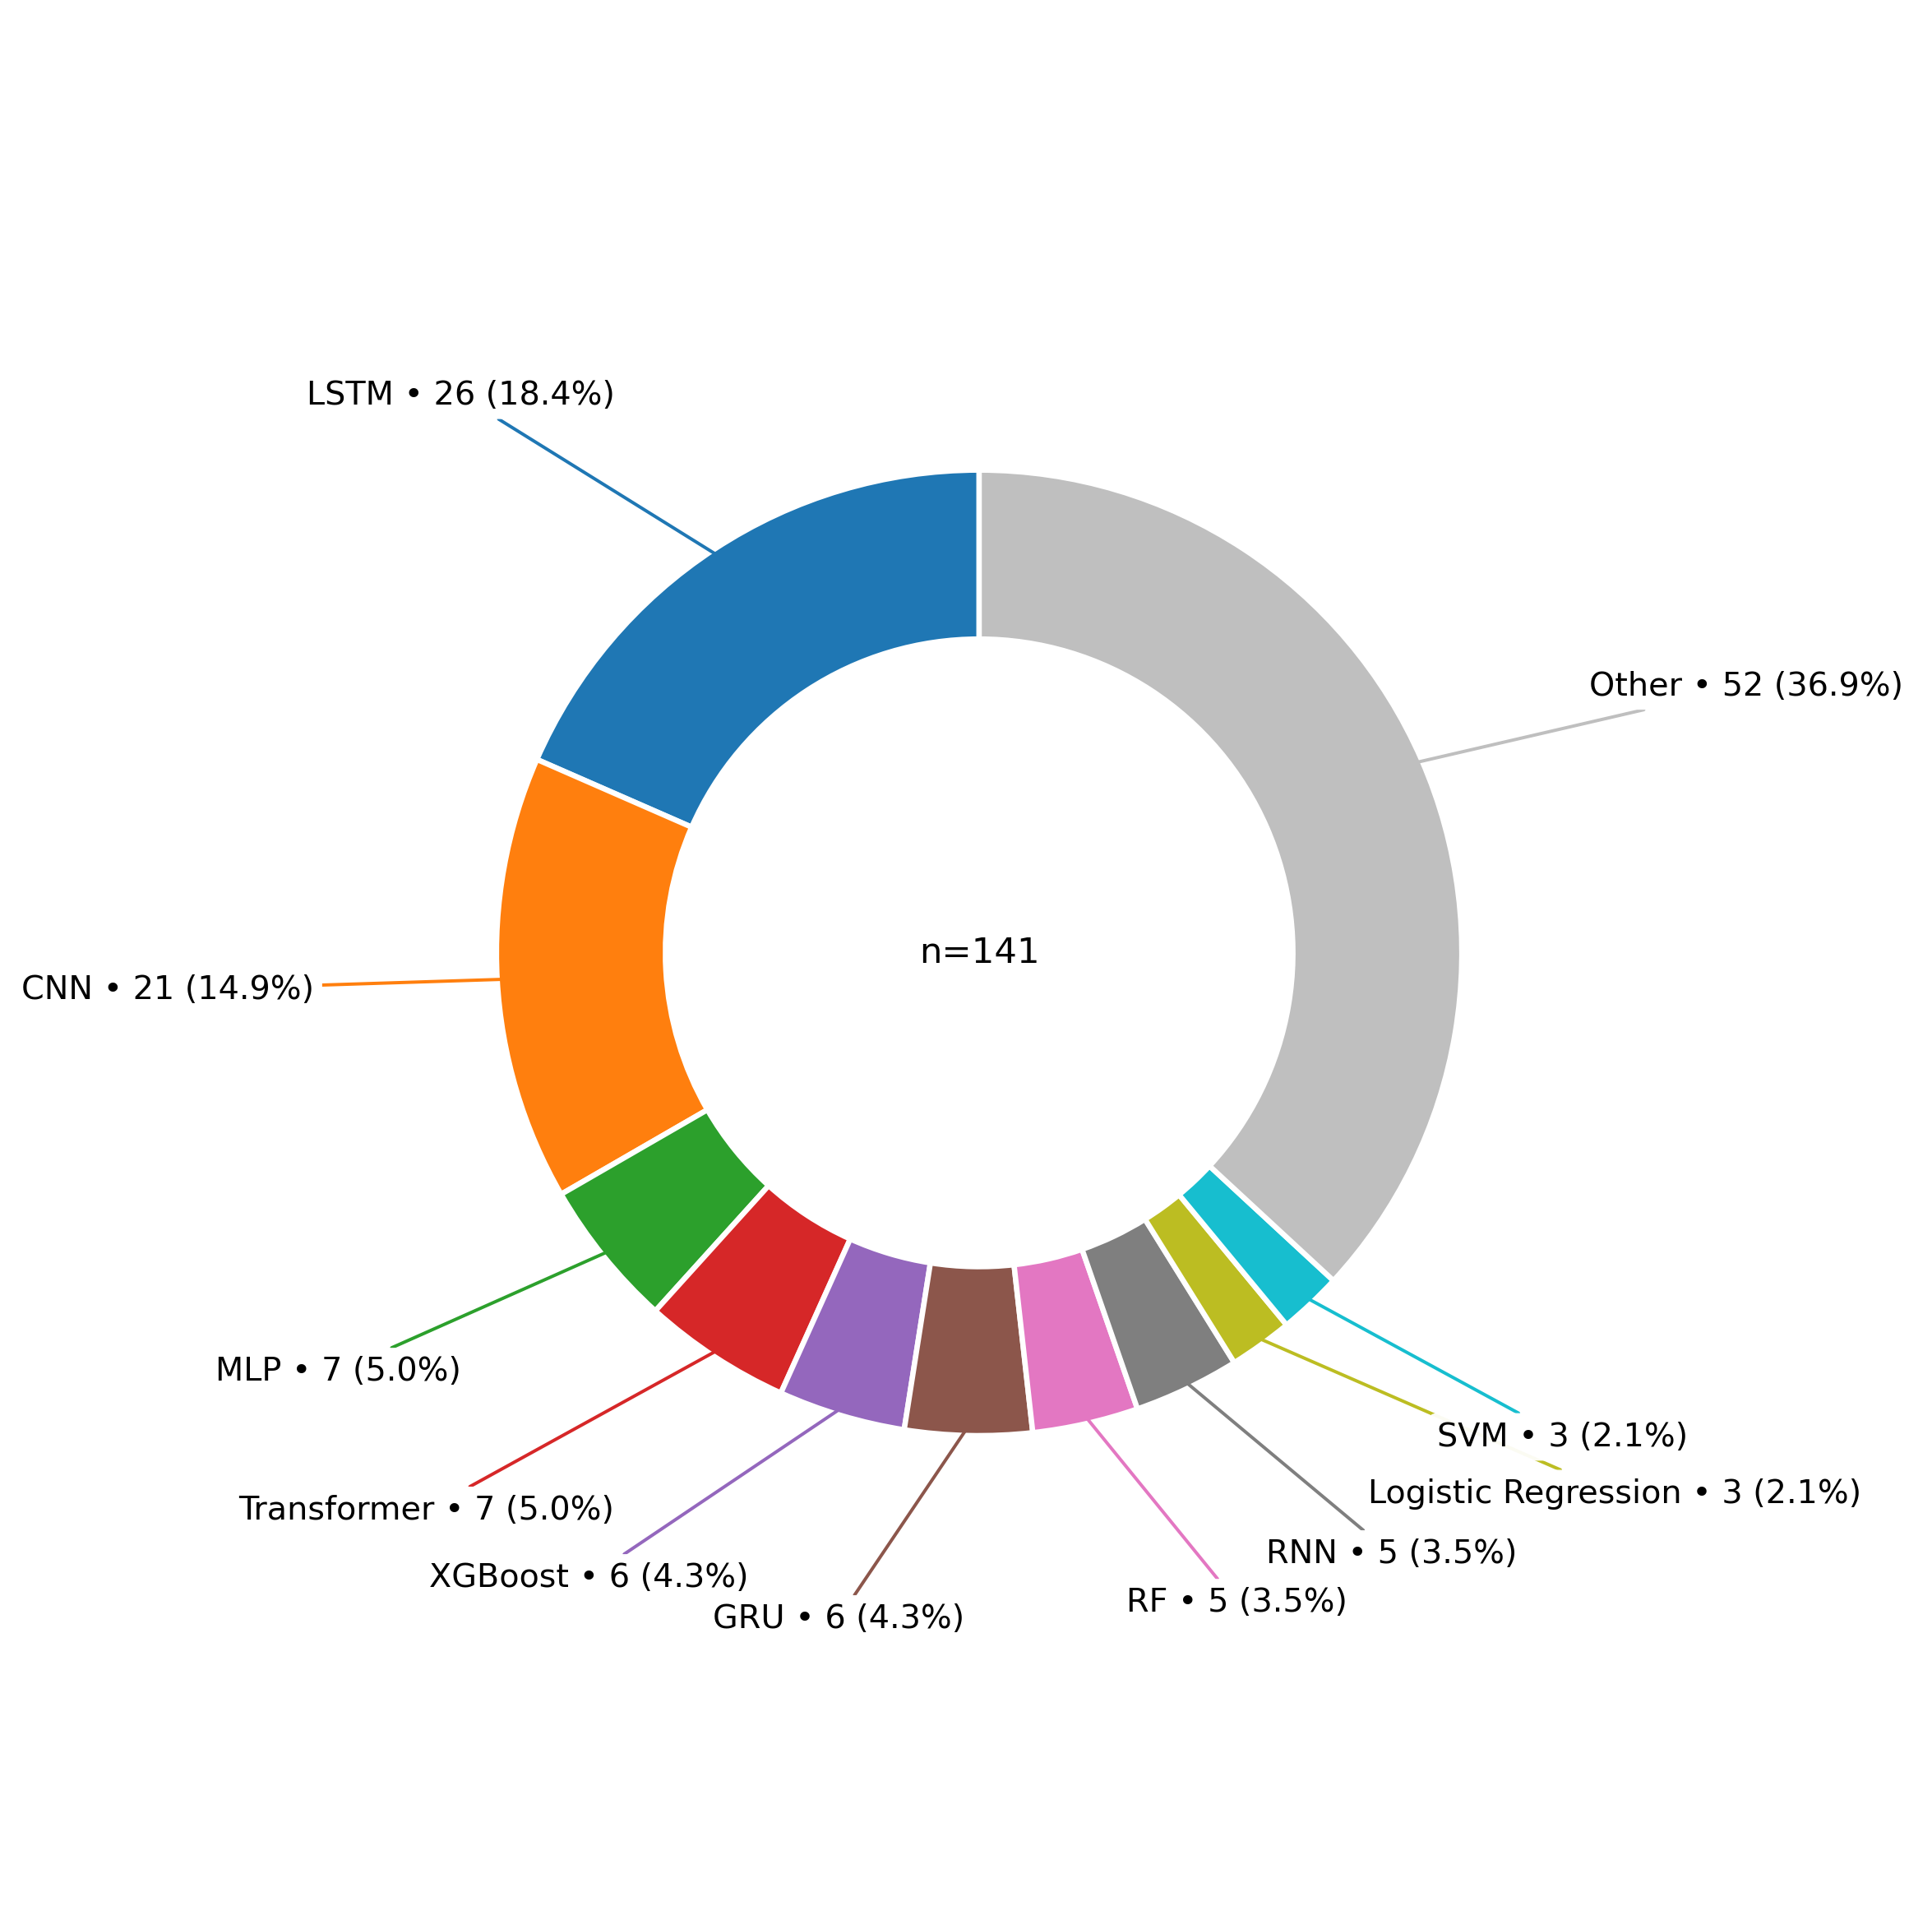

Saved to: ml_techniques_pie.png


In [15]:
import re, numpy as np, matplotlib.pyplot as plt
from itertools import cycle, islice
from datetime import datetime

# Config (optional, but done)
PREFERRED_COLS = ["ML Technique(s)"]  # tries in this order
MIN_PERCENT = 2.0    # group slices smaller than this % into "Other" (set to 0 to disable)
SAVE_PATH = None    

def pie_from_column_labeled(
    df,
    column=None,
    min_percent=MIN_PERCENT,
    save_path=SAVE_PATH,
    ring_width=0.35,
    label_radius=1.38,      # farther out = fewer collisions
    min_gap=0.085,          # larger vertical spacing between labels
    dpi_fig=260,
    dpi_save=450,
    abbreviate=True,
):
    if column is None:
        column = _pick_categorical_column(df)

    # clean
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()
    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]
    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")
    counts = s.value_counts().sort_values(ascending=False)

    if min_percent and min_percent > 0:
        thresh = min_percent / 100.0
        small = counts[counts / total < thresh]
        big = counts[counts / total >= thresh].drop(labels=["Other"], errors="ignore")
        other_sum = int(small.sum()) + int(counts.get("Other", 0))
        plot_counts = big.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum
    else:
        plot_counts = counts.drop(labels=["Other"], errors="ignore")
        if "Other" in counts:
            plot_counts.loc["Other"] = int(counts["Other"])

    labels = plot_counts.index.tolist()
    values = plot_counts.values
    total_plot = values.sum()

    # optional abbreviations for long names (prevents collisions)
    abbr = {
        "Long Short-Term Memory": "LSTM",
        "Convolutional Neural Network": "CNN",
        "Gated Recurrent Unit": "GRU",
        "Multi-Layer Perceptron": "MLP",
        "Extreme Gradient Boosting": "XGBoost",
        "Random Forest": "RF",
        "Deep Neural Network": "DNN",
        "Recurrent Neural Network": "RNN",
        "Support Vector Machine": "SVM",
    }
    disp = [abbr.get(l, l) if abbreviate else l for l in labels]

    # colors (Other → gray)
    base_cycle = plt.rcParams.get("axes.prop_cycle", None)
    base_colors = base_cycle.by_key().get("color", []) if base_cycle else []
    if not base_colors:
        base_colors = [plt.cm.tab20(i) for i in range(20)]
    colors = list(islice(cycle(base_colors), len(labels)))
    for i, lab in enumerate(labels):
        if str(lab).lower() == "other":
            colors[i] = (0.75, 0.75, 0.75, 1.0)

    # plot donut
    fig, ax = plt.subplots(figsize=(9.5, 9.5), dpi=dpi_fig)
    wedges, _ = ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={"linewidth": 1.8, "edgecolor": "white", "width": ring_width, "antialiased": True},
    )
    ax.set_aspect("equal")

    # initial label targets
    info = []
    for w, lab, disp_lab, val, col in zip(wedges, labels, disp, values, colors):
        ang = (w.theta2 + w.theta1) / 2.0
        rad = np.deg2rad(ang)
        x, y = np.cos(rad), np.sin(rad)
        info.append({"w": w, "lab": lab, "txt": f"{disp_lab} • {val} ({val/total_plot*100:.1f}%)",
                     "val": val, "col": col, "x": x, "y": y})

    # distribute per side with bigger minimum gap
    def _spread(side, R, gap):
        side.sort(key=lambda d: d["y"])
        ys = [d["y"] * R for d in side]
        for i in range(1, len(ys)):
            if ys[i] - ys[i-1] < gap:
                ys[i] = ys[i-1] + gap
        # clamp to range if needed
        if ys:
            offset = 0.0
            hi = R
            lo = -R
            if ys[-1] > hi: offset = hi - ys[-1]
            if ys[0] < lo:  offset = max(offset, lo - ys[0])
            ys = [y + offset for y in ys]
        for d, yv in zip(side, ys):
            sgn = 1 if d["x"] >= 0 else -1
            d["y_lab"] = yv
            d["x_lab"] = sgn * np.sqrt(max(R**2 - yv**2, 1e-6))
            d["ha"] = "left" if sgn > 0 else "right"

    right = [d for d in info if d["x"] >= 0]
    left  = [d for d in info if d["x"] <  0]
    _spread(right, label_radius, min_gap)
    _spread(left,  label_radius, min_gap)

    # draw annotations
    extras = []
    r_outer = 1.0
    for d in info:
        x_end, y_end = 0.98 * r_outer * d["x"], 0.98 * r_outer * d["y"]
        ann = ax.annotate(
            d["txt"],
            xy=(x_end, y_end),
            xytext=(d["x_lab"], d["y_lab"]),
            ha=d["ha"], va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.95),
            arrowprops=dict(arrowstyle="-", lw=1.1, color=d["col"], shrinkA=0, shrinkB=0),
        )
        extras.append(ann)

    # center total
    extras.append(ax.text(0, 0, f"n={total}", ha="center", va="center", fontsize=12))

    # spacious limits so labels never clip
    pad = 0.55
    lim = label_radius + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.tight_layout()

    # autosave if not provided
    if not save_path:
        safe_col = re.sub(r"[^A-Za-z0-9]+", "_", str(column)).strip("_").lower() or "pie"
        save_path = f"ml_techniques_pie.png"

    fig.savefig(
        save_path,
        dpi=dpi_save,
        bbox_inches="tight",
        bbox_extra_artists=extras,
        pad_inches=0.6,
    )
    plt.show()

    summary = plot_counts.to_frame("Count")
    summary["Percent"] = (summary["Count"] / total_plot * 100).round(2)
    return summary, save_path
summary, path = pie_from_column_labeled(df_ml_exp, column="ML Technique(s)")
print("Saved to:", path)

# This figure is eventually recreated in TikZ for Latex.

In [16]:
import pandas as pd
import re
import csv

def ml_technique_full_list_with_finance_split_refs(
    df,
    column="ML Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || ",
):
    # Clean ML technique column
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()

    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    # Base count table
    table = s.value_counts().rename("Count").to_frame()
    table["Percent"] = (table["Count"] / total * 100).round(2)

    # Required columns
    for c in (field_col, author_col):
        if c not in df.columns:
            raise KeyError(f"df must contain '{c}'.")

    # Align cleaned columns with df rows
    tech_clean = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    tech_clean = pd.Series(tech_clean, dtype="object")
    tech_clean = tech_clean.where(
        ~tech_clean.fillna("").str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings),
        other=None
    )

    field_clean = df[field_col].map(lambda x: "" if pd.isna(x) else str(x).strip())
    is_finance = field_clean.str.casefold().eq(finance_label)

    authors_clean = df[author_col].map(lambda x: None if pd.isna(x) else str(x).strip())
    authors_clean = pd.Series(authors_clean, dtype="object").replace({"": None})

    # Finance counts per technique 
    finance_counts = tech_clean[is_finance].dropna().value_counts()
    table["Finance Count"] = table.index.map(lambda t: int(finance_counts.get(t, 0)))
    table["Finance Share %"] = (table["Finance Count"] / table["Count"] * 100).round(2)

    # Split references
    fin_refs = {}
    nonfin_refs = {}

    for tech, is_fin, auth in zip(tech_clean, is_finance, authors_clean):
        if tech is None or auth is None:
            continue

        target = fin_refs if is_fin else nonfin_refs
        target.setdefault(tech, [])
        if auth not in target[tech]:
            target[tech].append(auth)

    table["Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(fin_refs.get(t, []))
    )
    table["Non-Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(nonfin_refs.get(t, []))
    )

    table.index.name = column
    return table.reset_index(), total


# run
ml_table, n_total = ml_technique_full_list_with_finance_split_refs(
    df_ml_exp,
    column="ML Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || "
)

ml_table.to_csv(
    "ml_technique_finance_split_refs.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print(f"Total non-empty entries: n={n_total}")
display(ml_table)

Total non-empty entries: n=141


,ML Technique(s),Count,Percent,Finance Count,Finance Share %,Financial References (Authors),Non-Financial References (Authors)
0,Long Short-Term Memory,26,18.44,6,23.08,"Park, H.J.; Kim, Y.; Kim, H.Y. || Giudici, P.;...","Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D...."
1,Convolutional Neural Network,21,14.89,2,9.52,"Valensky, D.; Mohaghegh, M. || Kumar, Devinder...","Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D...."
2,Multi-Layer Perceptron,7,4.96,1,14.29,"Parente, M.; Rizzuti, L.; Trerotola, M.","Abdullah, M.; Sulong, Z.; Ashraful Ferdous Cho..."
3,Transformer,7,4.96,0,0.00,,"Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D...."
4,Extreme Gradient Boosting,6,4.26,2,33.33,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z....","Kajári, B.; Tobak, Z.; Túri, N.; Bozán, C.; Va..."
5,Gated Recurrent Unit,6,4.26,2,33.33,"Giudici, P.; Piergallini, A.; Recchioni, M.C.;...","Sarker, M.A.A.; Shanmugam, B.; Azam, S.; Thenn..."
6,Random Forest,5,3.55,4,80.00,"Park, H.J.; Kim, Y.; Kim, H.Y. || Deng, S.; Zh...","Saleh, H.; ElRashidy, N.; Abd Elaziz, M.; O. A..."
7,Recurrent Neural Network,5,3.55,1,20.00,"Freeborough, W.; van Zyl, T.","Doddaiah, R.; Parvatharaju, P.S.; Rundensteine..."
8,Logistic Regression,3,2.13,1,33.33,"Muhammad, D.; Ahmed, I.; Naveed, K.; Bendechac...","Popov, P.; Mahmood, U.; Fu, Z.; Yang, C.; Calh..."
9,Support Vector Machine,3,2.13,2,66.67,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z....","Saleh, H.; ElRashidy, N.; Abd Elaziz, M.; O. A..."


Saved: heatmap_tech_vs_finance_subdomain.png


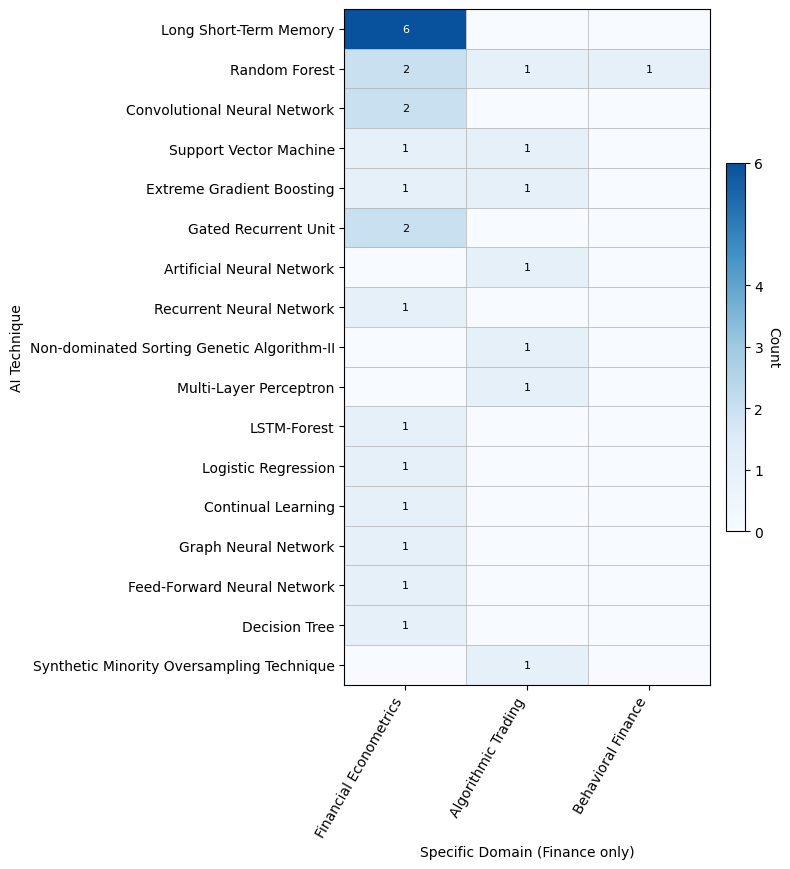

In [17]:
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_tech_vs_finance_subdomain_heatmap(
    df: pd.DataFrame,
    tech_col: str = "ML Technique(s)",
    domain_col: str = "Domain",
    subdomain_col: str | None = None,
    finance_label: str = "finance",
    rotate_xticks: int = 60,
    annotate: bool = True,
    other_min_total: int = 0,
    other_label: str = "Other",
    cmap: str = "magma",
    save: bool = True,
    out_path: str | None = None,
    dpi: int = 400,
):
    
    # column selection
    if subdomain_col is None:
        candidates = [
            "Specific Domain (Finance only)",
            "Finance Subdomain",
            "Specific Domain",
            "Subdomain",
        ]
        subdomain_col = next((c for c in candidates if c in df.columns), None)
        if subdomain_col is None:
            raise KeyError(
                "Couldn't find a finance subdomain column. "
                f"Tried: {', '.join(candidates)}"
            )

    missing = [c for c in [tech_col, domain_col, subdomain_col] if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    df2 = df.copy()

    # cleaning
    def _clean_str_col(s: pd.Series) -> pd.Series:
        # keep real NA as NA, strip whitespace for strings
        s = s.astype("string").str.strip()
        # remove NA-like literals (common after CSV round-trips)
        return s.mask(s.str.lower().isin({"<na>", "nan"}))

    df2[tech_col] = _clean_str_col(df2[tech_col])
    df2[domain_col] = _clean_str_col(df2[domain_col])
    df2[subdomain_col] = _clean_str_col(df2[subdomain_col])

    # Finance-only
    df2 = df2[df2[domain_col].str.lower().eq(finance_label).fillna(False)].copy()

    # Drop rows missing technique/subdomain
    df2 = df2.dropna(subset=[tech_col, subdomain_col]).copy()

    if df2.empty:
        raise ValueError(
            "No Finance rows with both technique and finance subdomain after cleaning."
        )

    # collapse rare techniques
    tech_counts = df2[tech_col].value_counts(dropna=False)
    rare = tech_counts[tech_counts < other_min_total].index
    if len(rare) > 0:
        df2[tech_col] = df2[tech_col].where(~df2[tech_col].isin(rare), other_label)

    # build count matrix
    mat = (
        df2.groupby([tech_col, subdomain_col])
        .size()
        .unstack(fill_value=0)
    )

    # order by totals; push "Other" last
    tech_order = mat.sum(axis=1).sort_values(ascending=False).index.tolist()
    if other_label in tech_order:
        tech_order = [t for t in tech_order if t != other_label] + [other_label]
    sub_order = mat.sum(axis=0).sort_values(ascending=False).index.tolist()

    mat = mat.reindex(index=tech_order, columns=sub_order)

    # plot sizing 
    n_tech, n_sub = mat.shape
    fig_w = float(np.clip(2 + 0.40 * n_sub, 8, 22))
    fig_h = float(np.clip(2 + 0.40 * n_tech, 6, 22))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(mat.to_numpy(), aspect="auto", interpolation="nearest", cmap=cmap, vmin=0)

    ax.set_xlabel(subdomain_col)
    ax.set_ylabel("AI Technique")

    ax.set_xticks(np.arange(n_sub))
    ax.set_xticklabels(sub_order, rotation=rotate_xticks, ha="right")

    ax.set_yticks(np.arange(n_tech))
    ax.set_yticklabels(tech_order)

    # subtle grid to separate cells
    ax.set_xticks(np.arange(-0.5, n_sub, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_tech, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotations
    if annotate:
        vmax = int(mat.to_numpy().max()) if mat.size else 0
        vmax = max(vmax, 1)
        arr = mat.to_numpy()

        for i in range(n_tech):
            for j in range(n_sub):
                v = int(arr[i, j])
                if v == 0:
                    continue
                ax.text(
                    j, i, str(v),
                    ha="center", va="center",
                    fontsize=8,
                    color=("white" if (v / vmax) > 0.55 else "black"),
                )

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Count", rotation=270, labelpad=12)

    local_max = int(mat.to_numpy().max()) if mat.size else 0
    if local_max <= 5:
        ticks = list(range(0, local_max + 1))
    else:
        ticks = np.linspace(0, local_max, 6, dtype=int)
        ticks = sorted(set(ticks.tolist()))
    cbar.set_ticks(ticks)
    cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

    # title (optional; uncomment if you like)
    # ax.set_title(f"ML Techniques × Finance Subdomain (rare < {other_min_total} → {other_label})", weight="bold")

    fig.tight_layout()

    # save
    if save:
        if out_path is None:
            out_path = f"heatmap_tech_vs_finance_subdomain.png"
        fig.savefig(out_path, dpi=dpi)
        print(f"Saved: {out_path}")

    return mat, fig, ax

from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "thesis_blue",
    ["#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"]
)

# usage
mat, fig, ax = plot_tech_vs_finance_subdomain_heatmap(
    df_ml_exp,
    tech_col="ML Technique(s)",              # <- matches your schema
    other_min_total=1,
    cmap=cmap
)

# Not really using this graphic but keeping it here.

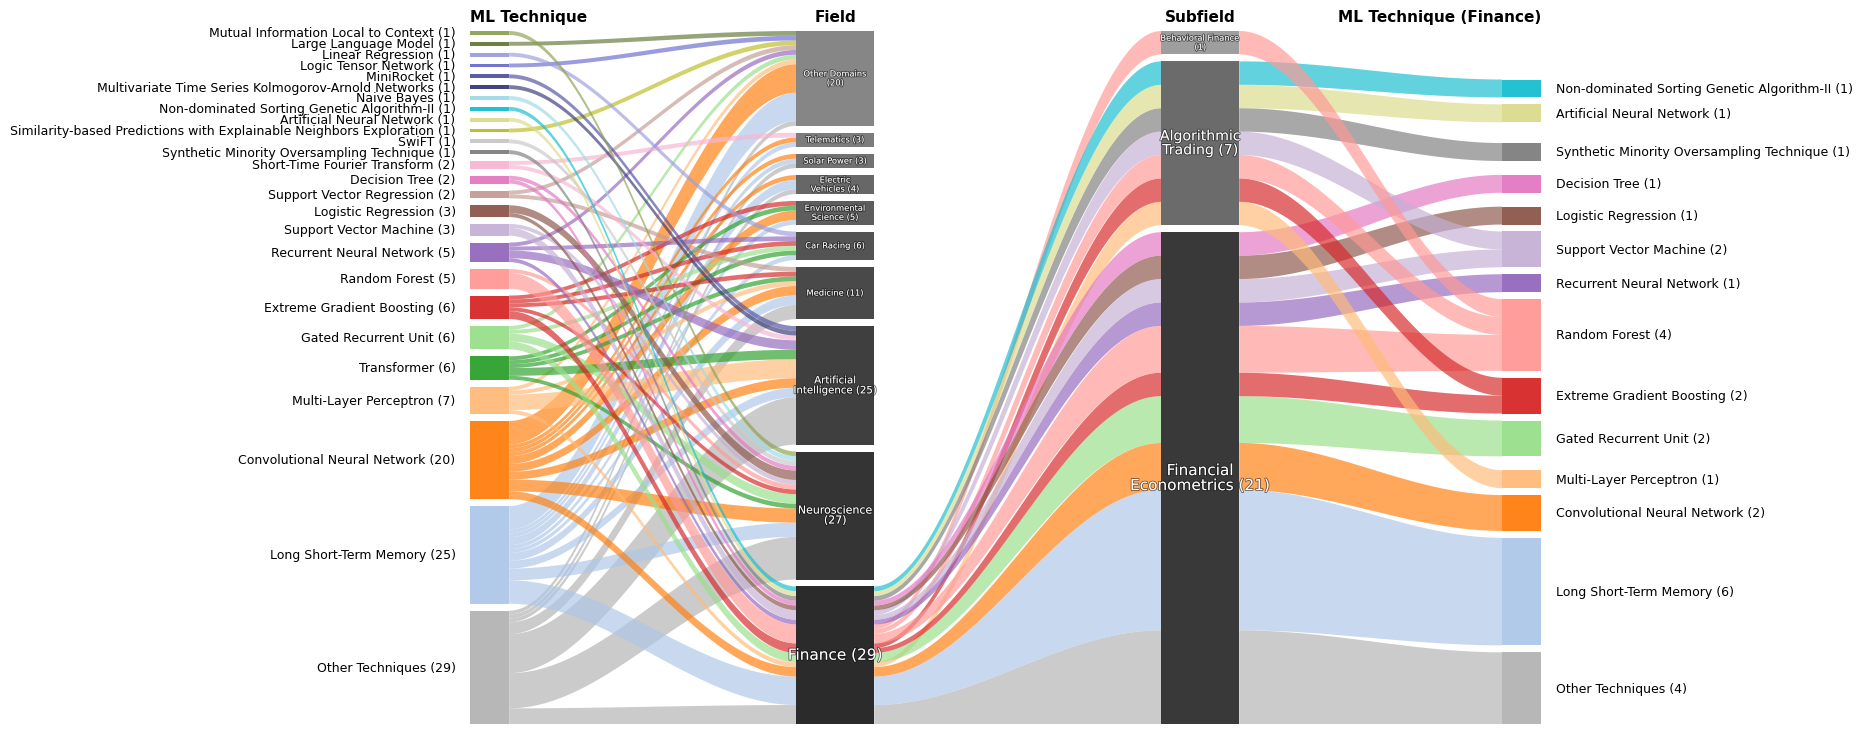

Saved: sankey_ml_field_subfield_ml.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib import patheffects as pe
import textwrap

# Config
TOP_TECH = 25
TOP_DOM  = 9
TOP_SPEC = 20

OTHER_TECH_LABEL = "Other Techniques"
OTHER_DOM_LABEL  = "Other Domains"
OTHER_SPEC_LABEL = "Other Finance"

BAR_W = 0.032
GAP = 0.01
LEFT_PAD, RIGHT_PAD = 0.012, 0.012
ALPHA_RIBBON, ALPHA_BAR = 0.68, 0.95

# Label rendering inside bars
DOMAIN_WRAP_CHARS = 16
SPEC_WRAP_CHARS   = 18
MIN_FONT_SIZE     = 6
MAX_FONT_SIZE     = 11
MIN_HEIGHT_FOR_TEXT = 0.018

# Column names
TECH_COL   = "ML Technique(s)"
DOMAIN_COL = "Domain"
SPEC_COL   = "Specific Domain (Finance only)"
FIN_LABEL  = "Finance"

# Safety checks
if "df_ml_exp" not in globals() or not isinstance(df_ml_exp, pd.DataFrame):
    raise NameError("df_ml_exp must be a pandas DataFrame in the current session.")

for c in [TECH_COL, DOMAIN_COL]:
    if c not in df_ml_exp.columns:
        raise KeyError(f"Missing required column: {c}")

# Prep / Clean
df_all = df_ml_exp.copy()

def _clean_col(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"<NA>": "", "<na>": "", "nan": "", "NaN": ""})
    return s.fillna("")

df_all[TECH_COL]   = _clean_col(df_all[TECH_COL])
df_all[DOMAIN_COL] = _clean_col(df_all[DOMAIN_COL])
df_all[SPEC_COL]   = _clean_col(df_all[SPEC_COL]) if SPEC_COL in df_all.columns else ""

df_all = df_all[(df_all[TECH_COL] != "") & (df_all[DOMAIN_COL] != "")]
if df_all.empty:
    raise ValueError(f"No rows with non-empty '{TECH_COL}' and '{DOMAIN_COL}'.")

# Finance-only subset
df_fin = df_all[df_all[DOMAIN_COL].str.casefold().eq(FIN_LABEL.casefold())].copy()
if df_fin.empty:
    raise ValueError("No Finance rows found. Sankey requires finance rows for the right legs.")
df_fin["__Spec"] = np.where(df_fin[SPEC_COL] != "", df_fin[SPEC_COL], "Finance (Unspecified)")

# Reduce cardinality
# Techniques
tech_tot_all = df_all.groupby(TECH_COL).size().sort_values(ascending=False)
tech_keep = tech_tot_all.index[:TOP_TECH].tolist() if len(tech_tot_all) > TOP_TECH else tech_tot_all.index.tolist()
df_all["__TechRed"] = np.where(df_all[TECH_COL].isin(tech_keep), df_all[TECH_COL], OTHER_TECH_LABEL)
df_fin["__TechRed"] = np.where(df_fin[TECH_COL].isin(tech_keep), df_fin[TECH_COL], OTHER_TECH_LABEL)

# Domains (TOP 9 + Other)
dom_tot_all = df_all.groupby(DOMAIN_COL).size().sort_values(ascending=False)
dom_keep = dom_tot_all.index[:TOP_DOM].tolist() if len(dom_tot_all) > TOP_DOM else dom_tot_all.index.tolist()
df_all["__DomRed"] = np.where(df_all[DOMAIN_COL].isin(dom_keep), df_all[DOMAIN_COL], OTHER_DOM_LABEL)
df_fin["__DomRed"] = np.where(df_fin[DOMAIN_COL].isin(dom_keep), df_fin[DOMAIN_COL], OTHER_DOM_LABEL)

# Finance subdomains
spec_tot_all_fin = df_fin.groupby("__Spec").size().sort_values(ascending=False)
spec_keep = spec_tot_all_fin.index[:TOP_SPEC].tolist() if len(spec_tot_all_fin) > TOP_SPEC else spec_tot_all_fin.index.tolist()
df_fin["__SpecRed"] = np.where(df_fin["__Spec"].isin(spec_keep), df_fin["__Spec"], OTHER_SPEC_LABEL)

# Flow tables
flows_T_D = df_all.groupby(["__TechRed", "__DomRed"]).size().unstack(fill_value=0)
flows_T_S_fin = df_fin.groupby(["__TechRed", "__SpecRed"]).size().unstack(fill_value=0)

# Node totals & orders
tech_tot_left = flows_T_D.sum(axis=1).sort_values(ascending=False)
dom_totals    = flows_T_D.sum(axis=0).sort_values(ascending=False)

# keep "Other Domains" last
dom_order = dom_totals.index.tolist()
if OTHER_DOM_LABEL in dom_order:
    dom_order = [d for d in dom_order if d != OTHER_DOM_LABEL] + [OTHER_DOM_LABEL]
flows_T_D = flows_T_D.reindex(index=tech_tot_left.index, columns=dom_order, fill_value=0)

spec_totals = flows_T_S_fin.sum(axis=0).sort_values(ascending=False)

# keep "Other Finance" last
spec_order = spec_totals.index.tolist()
if OTHER_SPEC_LABEL in spec_order:
    spec_order = [s for s in spec_order if s != OTHER_SPEC_LABEL] + [OTHER_SPEC_LABEL]
flows_T_S_fin = flows_T_S_fin.reindex(index=tech_tot_left.index, columns=spec_order, fill_value=0)

# right-tech totals align to ALL-tech order
tech_tot_right = flows_T_S_fin.sum(axis=1).reindex(tech_tot_left.index, fill_value=0)

tech_labels = tech_tot_left.index.tolist()
dom_labels  = flows_T_D.columns.tolist()
spec_labels = flows_T_S_fin.columns.tolist()
tech_right_labels = tech_labels[:]  # same order on the right

# Colors
def make_color_map(labels):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])
    if len(colors) < len(labels):
        need = len(labels) - len(colors)
        hsv = plt.get_cmap("hsv", need + 1)
        colors.extend([hsv(i) for i in range(need)])
    mapping = {lab: colors[i] for i, lab in enumerate(labels)}
    if OTHER_TECH_LABEL in mapping:
        mapping[OTHER_TECH_LABEL] = (0.7, 0.7, 0.7, 1.0)
    return mapping

color_by_tech = make_color_map(tech_labels)

def greyscale_list(n, lo=0.12, hi=0.55):
    if n <= 0:
        return []
    vals = np.linspace(lo, hi, n)
    return [(v, v, v, 1.0) for v in vals]

domain_colors = {d: c for d, c in zip(dom_labels, greyscale_list(len(dom_labels), lo=0.12, hi=0.50))}
spec_colors   = {s: c for s, c in zip(spec_labels, greyscale_list(len(spec_labels), lo=0.18, hi=0.60))}

# Layout helpers
def stack_positions(values, total_height=1.0, gap=GAP):
    vals = np.asarray(values, dtype=float)
    s = vals.sum()
    usable = max(total_height - gap * max(len(vals) - 1, 0), 0.0)
    heights = np.zeros_like(vals) if s <= 0 else (vals / s) * usable
    y0, y = [], 0.0
    for h in heights:
        y0.append(y)
        y += h + gap
    y0 = np.array(y0)
    y1 = y0 + heights
    return y0, y1, heights

def cubic_bezier(P0, P1, P2, P3, ts):
    ts = np.asarray(ts)[:, None]
    return ((1-ts)**3)*P0 + 3*((1-ts)**2)*ts*P1 + 3*(1-ts)*(ts**2)*P2 + (ts**3)*P3

def draw_ribbon(ax, x0, y0_top, y0_bot, x1, y1_top, y1_bot, color, curvature=0.35, n=100, alpha=ALPHA_RIBBON):
    P0 = np.array([x0, y0_top]);  P3 = np.array([x1, y1_top]);  dx = x1 - x0
    P1 = P0 + np.array([dx*curvature, 0.0]);  P2 = P3 - np.array([dx*curvature, 0.0])
    ts = np.linspace(0, 1, n)
    top = cubic_bezier(P0, P1, P2, P3, ts)

    P0b = np.array([x0, y0_bot]);  P3b = np.array([x1, y1_bot])
    P1b = P0b + np.array([dx*curvature, 0.0]);  P2b = P3b - np.array([dx*curvature, 0.0])
    bot = cubic_bezier(P0b, P1b, P2b, P3b, ts)

    verts = np.vstack([top, bot[::-1], top[:1]])
    codes = [Path.MOVETO] + [Path.LINETO]*(top.shape[0]-1) + [Path.LINETO]*bot.shape[0] + [Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts, codes), lw=0, facecolor=color, alpha=alpha))

# Label bars: max 2 lines, adaptive wrap, ellipsis if too long
def draw_labeled_bar(ax, x_left, y0, height, width, facecolor, label, wrap_chars=14):
    if height <= 0:
        return

    ax.add_patch(Rectangle((x_left, y0), width, height, lw=0,
                           facecolor=facecolor, alpha=ALPHA_BAR))

    if height < MIN_HEIGHT_FOR_TEXT or not label:
        return

    base = max(8, int(round(wrap_chars * (width / (2 * BAR_W)))))
    wrap = int(np.clip(base, 8, 26))

    lines = textwrap.wrap(label, width=wrap) or [label]
    if len(lines) > 2:
        lines = lines[:2]
        if len(lines[1]) >= 2:
            lines[1] = lines[1][:-1] + "…"

    txt = "\n".join(lines)

    fs = (height * 120) / (len(lines) + 0.8)
    fs = float(np.clip(fs, MIN_FONT_SIZE, MAX_FONT_SIZE))

    t = ax.text(
        x_left + width/2, y0 + height/2, txt,
        ha="center", va="center", fontsize=fs, color="white",
        clip_on=True, linespacing=1.0
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground=(0, 0, 0, 0.55))])

# Label forcing
# Add special cases here for labels you *must* show fully inside the bar.
def domain_label_text(dom: str, count: int) -> str:
    dom_str = str(dom)
    if dom_str == "Artificial Intelligence":
        # forced break ensures "(n)" stays visible and no truncation occurs
        return f"Artificial\nIntelligence ({count})"
    return f"{dom_str} ({count})"

# Optional: if you have a specific subdomain that also gets cut, add it here
def spec_label_text(spec: str, count: int) -> str:
    spec_str = str(spec)
    # Example special case (edit/remove as needed):
    # if spec_str == "Some Very Long Subdomain Name":
    #     return f"Some Very Long\nSubdomain Name ({count})"
    return f"{spec_str} ({count})"

# Positions
x0, x1, x2, x3 = 0.06, 0.36, 0.66, 0.94

yl0, yl1, hl = stack_positions(tech_tot_left.values)
ym0, ym1, hm = stack_positions(flows_T_D.sum(axis=0).values)
ys0, ys1, hs = stack_positions(spec_totals.values)
yr0, yr1, hr = stack_positions(tech_tot_right.values)

# Slices for ribbons
slice_TD_left, slice_TD_right = {}, {}

for i, tech in enumerate(tech_labels):
    total_i, y = tech_tot_left.values[i], yl0[i]
    if total_i <= 0:
        continue
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_i == 0 else (f / total_i) * hl[i]
        slice_TD_left[(tech, dom)] = (y + h, y)
        y += h

for j, dom in enumerate(dom_labels):
    total_j, y = flows_T_D[dom].sum(), ym0[j]
    if total_j <= 0:
        continue
    for tech in tech_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_j == 0 else (f / total_j) * hm[j]
        slice_TD_right[(tech, dom)] = (y + h, y)
        y += h

slice_FS_left, slice_FS_right = {}, {}
slice_ST_left, slice_ST_right = {}, {}

if FIN_LABEL in dom_labels:
    # B left: Finance segment split by subdomain
    for tech in tech_labels:
        seg = slice_TD_right.get((tech, FIN_LABEL))
        tech_fin_total = flows_T_D.loc[tech, FIN_LABEL] if FIN_LABEL in flows_T_D.columns else 0
        if (not seg) or tech_fin_total <= 0:
            continue
        seg_top, seg_bot = seg
        seg_h = seg_top - seg_bot
        y = seg_bot
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * seg_h
            slice_FS_left[(tech, spec)] = (y + h, y)
            y += h

    # B right: stack incoming techniques for each subdomain
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_FS_right[(tech, spec)] = (y + h, y)
            y += h

    # C left/right: subdomain -> right-tech
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_right_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_ST_left[(spec, tech)] = (y + h, y)
            y += h

    for i, tech in enumerate(tech_right_labels):
        tech_fin_total, y = tech_tot_right.loc[tech], yr0[i]
        if tech_fin_total <= 0:
            continue
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * hr[i]
            slice_ST_right[(spec, tech)] = (y + h, y)
            y += h

# Plot
fig, ax = plt.subplots(figsize=(15.7, 9.0))
for s in ax.spines.values():
    s.set_visible(False)
ax.set_axis_off()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# A) Technique to Domain (ALL)
for tech in tech_labels:
    col = color_by_tech[tech]
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        if f <= 0:
            continue
        yL_top, yL_bot = slice_TD_left[(tech, dom)]
        yR_top, yR_bot = slice_TD_right[(tech, dom)]
        draw_ribbon(ax, x0 + BAR_W, yL_top, yL_bot, x1 - BAR_W, yR_top, yR_bot, color=col)

# B) Finance to Subdomain
if FIN_LABEL in dom_labels:
    for tech in tech_labels:
        for spec in spec_labels:
            key = (tech, spec)
            if key not in slice_FS_left or key not in slice_FS_right:
                continue
            yL_top, yL_bot = slice_FS_left[key]
            yR_top, yR_bot = slice_FS_right[key]
            draw_ribbon(ax, x1 + BAR_W, yL_top, yL_bot, x2 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# C) Subdomain to Technique (right)
for spec in spec_labels:
    for tech in tech_right_labels:
        key = (spec, tech)
        if key not in slice_ST_left or key not in slice_ST_right:
            continue
        yL_top, yL_bot = slice_ST_left[key]
        yR_top, yR_bot = slice_ST_right[key]
        draw_ribbon(ax, x2 + BAR_W, yL_top, yL_bot, x3 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# Bars: Left techniques
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.add_patch(Rectangle((x0, yl0[i]), BAR_W, hl[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Bars: Domains (TOP 9 + Other) with forced-label support
for j, dom in enumerate(dom_labels):
    if hm[j] <= 0:
        continue
    count_dom = int(flows_T_D[dom].sum())
    draw_labeled_bar(
        ax,
        x_left=(x1 - BAR_W),
        y0=ym0[j],
        height=hm[j],
        width=2*BAR_W,
        facecolor=domain_colors[dom],
        label=domain_label_text(dom, count_dom),
        wrap_chars=22 if str(dom) == "Artificial Intelligence" else DOMAIN_WRAP_CHARS
    )

# Bars: Finance subdomains (with optional forced-label support)
for k, spec in enumerate(spec_labels):
    if hs[k] <= 0:
        continue
    count_spec = int(spec_totals.loc[spec])
    # If you want forced wrapping for particular specs, do it in spec_label_text()
    draw_labeled_bar(
        ax,
        x_left=(x2 - BAR_W),
        y0=ys0[k],
        height=hs[k],
        width=2*BAR_W,
        facecolor=spec_colors[spec],
        label=spec_label_text(spec, count_spec),
        wrap_chars=SPEC_WRAP_CHARS
    )

# Bars: Right techniques (touch ribbons)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.add_patch(Rectangle((x3 - BAR_W, yr0[i]), BAR_W, hr[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Left technique labels
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.text(x0 - LEFT_PAD, (yl0[i] + yl1[i]) / 2, f"{tech} ({int(tech_tot_left.loc[tech])})",
                ha="right", va="center", fontsize=9, clip_on=False)

# Right technique labels (skip zeros to reduce clutter)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.text(x3 + RIGHT_PAD, (yr0[i] + yr1[i]) / 2, f"{tech} ({int(tech_tot_right.loc[tech])})",
                ha="left", va="center", fontsize=9, clip_on=False)

# Column titles
ax.text(x0, 1.01, "ML Technique",           ha="left",   va="bottom", fontsize=11, weight="bold")
ax.text(x1, 1.01, "Field",                  ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x2, 1.01, "Subfield",               ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x3, 1.01, "ML Technique (Finance)", ha="right",  va="bottom", fontsize=11, weight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

png_path = "sankey_ml_field_subfield_ml.png"
fig.savefig(png_path, dpi=1000, bbox_inches="tight")
print(f"Saved: {png_path}")


In [19]:
# Underlying Sankey tables (recreating purposes)

# 1) ML Technique (ALL) -> Domain (ALL)
table_tech_domain = (
    flows_T_D
    .stack()
    .reset_index()
    .rename(columns={"__TechRed": "ML Technique", "__DomRed": "Domain", 0: "Count"})
)
table_tech_domain = table_tech_domain[table_tech_domain["Count"] > 0]

# 2) Finance-only ML Technique -> Finance Subdomain
table_tech_subdomain_fin = (
    flows_T_S_fin
    .stack()
    .reset_index()
    .rename(columns={"__TechRed": "ML Technique", "__SpecRed": "Finance Subdomain", 0: "Count"})
)
table_tech_subdomain_fin = table_tech_subdomain_fin[table_tech_subdomain_fin["Count"] > 0]

# 3) Full Finance path:
# ML Technique (ALL reduced) -> Finance -> Finance Subdomain -> ML Technique (Finance-only)
table_finance_path = table_tech_subdomain_fin.copy()
table_finance_path.insert(1, "Domain", FIN_LABEL)
table_finance_path["ML Technique (Finance-only)"] = table_finance_path["ML Technique"]

# Optional: totals table for nodes
table_nodes = pd.concat([
    tech_tot_left.rename("Count").reset_index().rename(columns={"index": "Node"}).assign(Level="ML Technique"),
    dom_totals.rename("Count").reset_index().rename(columns={"index": "Node"}).assign(Level="Domain"),
    spec_totals.rename("Count").reset_index().rename(columns={"index": "Node"}).assign(Level="Finance Subdomain"),
    tech_tot_right.rename("Count").reset_index().rename(columns={"index": "Node"}).assign(Level="ML Technique (Finance-only)")
], ignore_index=True)

# Display
print("Technique -> Domain")
display(table_tech_domain)

print("Finance Technique -> Subdomain")
display(table_tech_subdomain_fin)

print("Full Finance Path")
display(table_finance_path)

print("Node Totals")
display(table_nodes)

# Optional: save to Excel
xlsx_path = "sankey_ml_underlying_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    table_tech_domain.to_excel(writer, sheet_name="Tech_to_Domain", index=False)
    table_tech_subdomain_fin.to_excel(writer, sheet_name="Finance_Tech_to_Subdomain", index=False)
    table_finance_path.to_excel(writer, sheet_name="Finance_Path", index=False)
    table_nodes.to_excel(writer, sheet_name="Node_Totals", index=False)

print(f"Saved: {xlsx_path}")

Technique -> Domain


,ML Technique,Domain,Count
0,Other Techniques,Finance,4
1,Other Techniques,Neuroscience,9
2,Other Techniques,Artificial Intelligence,10
3,Other Techniques,Medicine,3
6,Other Techniques,Electric Vehicles,1
...,...,...,...
212,MiniRocket,Artificial Intelligence,1
229,Logic Tensor Network,Other Domains,1
234,Linear Regression,Car Racing,1
249,Large Language Model,Other Domains,1


Finance Technique -> Subdomain


,ML Technique,Finance Subdomain,Count
0,Other Techniques,Financial Econometrics,4
3,Long Short-Term Memory,Financial Econometrics,6
6,Convolutional Neural Network,Financial Econometrics,2
10,Multi-Layer Perceptron,Algorithmic Trading,1
15,Gated Recurrent Unit,Financial Econometrics,2
18,Extreme Gradient Boosting,Financial Econometrics,1
19,Extreme Gradient Boosting,Algorithmic Trading,1
21,Random Forest,Financial Econometrics,2
22,Random Forest,Algorithmic Trading,1
23,Random Forest,Behavioral Finance,1


Full Finance Path


,ML Technique,Domain,Finance Subdomain,Count,ML Technique (Finance-only)
0,Other Techniques,Finance,Financial Econometrics,4,Other Techniques
3,Long Short-Term Memory,Finance,Financial Econometrics,6,Long Short-Term Memory
6,Convolutional Neural Network,Finance,Financial Econometrics,2,Convolutional Neural Network
10,Multi-Layer Perceptron,Finance,Algorithmic Trading,1,Multi-Layer Perceptron
15,Gated Recurrent Unit,Finance,Financial Econometrics,2,Gated Recurrent Unit
18,Extreme Gradient Boosting,Finance,Financial Econometrics,1,Extreme Gradient Boosting
19,Extreme Gradient Boosting,Finance,Algorithmic Trading,1,Extreme Gradient Boosting
21,Random Forest,Finance,Financial Econometrics,2,Random Forest
22,Random Forest,Finance,Algorithmic Trading,1,Random Forest
23,Random Forest,Finance,Behavioral Finance,1,Random Forest


Node Totals


,__TechRed,Count,Level,__DomRed,__SpecRed
0,Other Techniques,29,ML Technique,NaN,NaN
1,Long Short-Term Memory,25,ML Technique,NaN,NaN
2,Convolutional Neural Network,20,ML Technique,NaN,NaN
3,Multi-Layer Perceptron,7,ML Technique,NaN,NaN
4,Transformer,6,ML Technique,NaN,NaN
...,...,...,...,...,...
60,MiniRocket,0,ML Technique (Finance-only),NaN,NaN
61,Logic Tensor Network,0,ML Technique (Finance-only),NaN,NaN
62,Linear Regression,0,ML Technique (Finance-only),NaN,NaN
63,Large Language Model,0,ML Technique (Finance-only),NaN,NaN


Saved: sankey_ml_underlying_tables.xlsx


### **Create Insights for XAI**

In [21]:
df_xai = df_ml_exp.copy()
df_xai.columns.tolist()

['\ufeffKey',
 'Item Type',
 'Publication Year',
 'Author',
 'Title_zotero',
 'Publication Title',
 'ISBN',
 'ISSN',
 'DOI',
 'Url',
 'Abstract Note',
 'Date',
 'Date Added',
 'Date Modified',
 'Access Date',
 'Pages',
 'Num Pages',
 'Issue',
 'Volume',
 'Number Of Volumes',
 'Journal Abbreviation',
 'Short Title',
 'Series',
 'Series Number',
 'Series Text',
 'Series Title',
 'Publisher',
 'Place',
 'Language',
 'Rights',
 'Type',
 'Archive',
 'Archive Location',
 'Library Catalog',
 'Call Number',
 'Extra',
 'Notes',
 'File Attachments',
 'Link Attachments',
 'Manual Tags',
 'Automatic Tags',
 'Editor',
 'Series Editor',
 'Translator',
 'Contributor',
 'Attorney Agent',
 'Book Author',
 'Cast Member',
 'Commenter',
 'Composer',
 'Cosponsor',
 'Counsel',
 'Interviewer',
 'Producer',
 'Recipient',
 'Reviewed Author',
 'Scriptwriter',
 'Words By',
 'Guest',
 'Number',
 'Edition',
 'Running Time',
 'Scale',
 'Medium',
 'Artwork Size',
 'Filing Date',
 'Application Number',
 'Assignee',
 

In [22]:
import re
import pandas as pd

# Helpers (same as ML version, not changed)

_ABBR_RE = re.compile(r"^[A-Z][A-Z0-9\-]{1,}$")  # e.g., SHAP, LIME, IG, PDP, ALE

def _parse_tech(part: str) -> tuple[str, str]:
    """
    'Integrated Gradients (IG)' -> ('Integrated Gradients', 'IG')
    'IG' -> ('IG', 'IG')
    'Partial Dependence Plot' -> ('Partial Dependence Plot', '')
    """
    part = (part or "").strip()
    if not part:
        return "", ""

    m = re.match(r"^\s*(.*?)\s*(?:\((.*?)\))?\s*$", part)
    full = (m.group(1) if m else part).strip(" .;")
    abbr = (m.group(2) if (m and m.group(2)) else "").strip(" .;")

    if not abbr and _ABBR_RE.match(full):
        abbr = full

    return full, abbr

def _colon_aware_items(cell: object) -> list[tuple[str, str | None]]:

    if cell is None or (isinstance(cell, float) and pd.isna(cell)):
        return []
    text = str(cell).strip()
    if not text:
        return []

    # Treat both ',' and ';' as item separators
    toks = [t.strip() for t in re.split(r"\s*[,;]\s*", text) if t.strip()]

    items: list[tuple[str, str | None]] = []
    for tok in toks:
        if ":" in tok:
            head, tail = tok.split(":", 1)
            head = head.strip()
            tail = tail.strip()
            items.append((head, tail if tail else None))
        else:
            items.append((tok, None))

    return items

# Build df_xai from df_ml (colon-aware explode)

base = df_ml.copy()

src_col  = "XAI Technique(s)"
abbr_col = "XAI Techniques (Abbreviation)"   # will be created/overwritten
ext_col  = "XAI Techniques Extended"         # will be created

# Ensure target cols exist (optional, but convenient)
for c in [abbr_col, ext_col]:
    if c not in base.columns:
        base[c] = ""

# Build list of (general, specific) pairs per row
base["__items"] = base[src_col].apply(_colon_aware_items)

# Explode to one row per item
df_xai = base.explode("__items", ignore_index=True)
df_xai = df_xai[df_xai["__items"].notna()].copy()

def _expand_xai(item):
    general_raw, specific_raw = item

    gen_full, gen_abbr = _parse_tech(general_raw)
    spec_full, spec_abbr = _parse_tech(specific_raw) if specific_raw else ("", "")

    # Keep the "general" in XAI Technique(s), put the specific in Extended
    return pd.Series({
        src_col: gen_full,
        abbr_col: gen_abbr,
        ext_col: spec_full,
        # Optional: if you want abbr for the specific too, uncomment:
        # "XAI Techniques Extended (Abbreviation)": spec_abbr
    })

df_xai[[src_col, abbr_col, ext_col]] = df_xai["__items"].apply(_expand_xai)

# Clean types/whitespace
for c in [src_col, abbr_col, ext_col]:
    df_xai[c] = df_xai[c].astype("string").str.strip()

# Drop helper
df_xai.drop(columns=["__items"], inplace=True)

# Peek rows where "XAI Techniques Extended" is not empty
mask = df_xai[ext_col].fillna("").astype(str).str.strip().ne("")
df_xai.to_csv("df_xai.csv", index=False, encoding="utf-8")

df_xai.loc[mask].head()


,﻿Key,Item Type,Publication Year,Author,Title_zotero,Publication Title,ISBN,ISSN,DOI,Url,...,Field,Novelty / Application,Limitations (if mentioned),Future Directions (if any),Year,Domain,Specific Domain (Finance only),ML Techniques (Abbreviation),XAI Techniques (Abbreviation),XAI Techniques Extended
5,MT3KUHCR,conferencePaper,2023,"Valensky, D.; Mohaghegh, M.",Evaluating Transparency: A Cross-Model Explora...,Proc. IEEE Asia-Pacific Conf. Comput. Sci. Dat...,979-835034107-2 (ISBN),NaN,10.1109/CSDE59766.2023.10487732,https://www.scopus.com/inward/record.uri?eid=2...,...,Finance,Application,The LSTM and CNN models used were relatively s...,Adapt XAI methods to deep learning models that...,2023.0,Finance,Financial Econometrics,,,Permutation Importance
12,EVDW9JZD,journalArticle,2022,"Freeborough, W.; van Zyl, T.",Investigating Explainability Methods in Recurr...,Applied Sciences (Switzerland),NaN,20763417 (ISSN),10.3390/app12031427,https://www.scopus.com/inward/record.uri?eid=2...,...,Finance,Application,Methods applied here were not tested on a comp...,Studies should expand to see if employed metho...,2022.0,Finance,Financial Econometrics,,,Feature Ablation
14,EVDW9JZD,journalArticle,2022,"Freeborough, W.; van Zyl, T.",Investigating Explainability Methods in Recurr...,Applied Sciences (Switzerland),NaN,20763417 (ISSN),10.3390/app12031427,https://www.scopus.com/inward/record.uri?eid=2...,...,Finance,Application,Methods applied here were not tested on a comp...,Studies should expand to see if employed metho...,2022.0,Finance,Financial Econometrics,,,Permutation Importance
16,3JTDECSM,journalArticle,2024,"Nguyen, T.T.; Le Nguyen, T.; Ifrim, G.",Robust explainer recommendation for time serie...,Data Min. Knowl. Discov.,NaN,NaN,10.1007/s10618-024-01045-8,https://www.scopus.com/inward/record.uri?eid=2...,...,Medicine,Novelty,NaN,Could be adapted to other types of data (such ...,2024.0,Medicine,,,SHAP,GradientSHAP
19,3JTDECSM,journalArticle,2024,"Nguyen, T.T.; Le Nguyen, T.; Ifrim, G.",Robust explainer recommendation for time serie...,Data Min. Knowl. Discov.,NaN,NaN,10.1007/s10618-024-01045-8,https://www.scopus.com/inward/record.uri?eid=2...,...,Medicine,Novelty,NaN,Could be adapted to other types of data (such ...,2024.0,Medicine,,,SHAP,ROCKET-SHAP


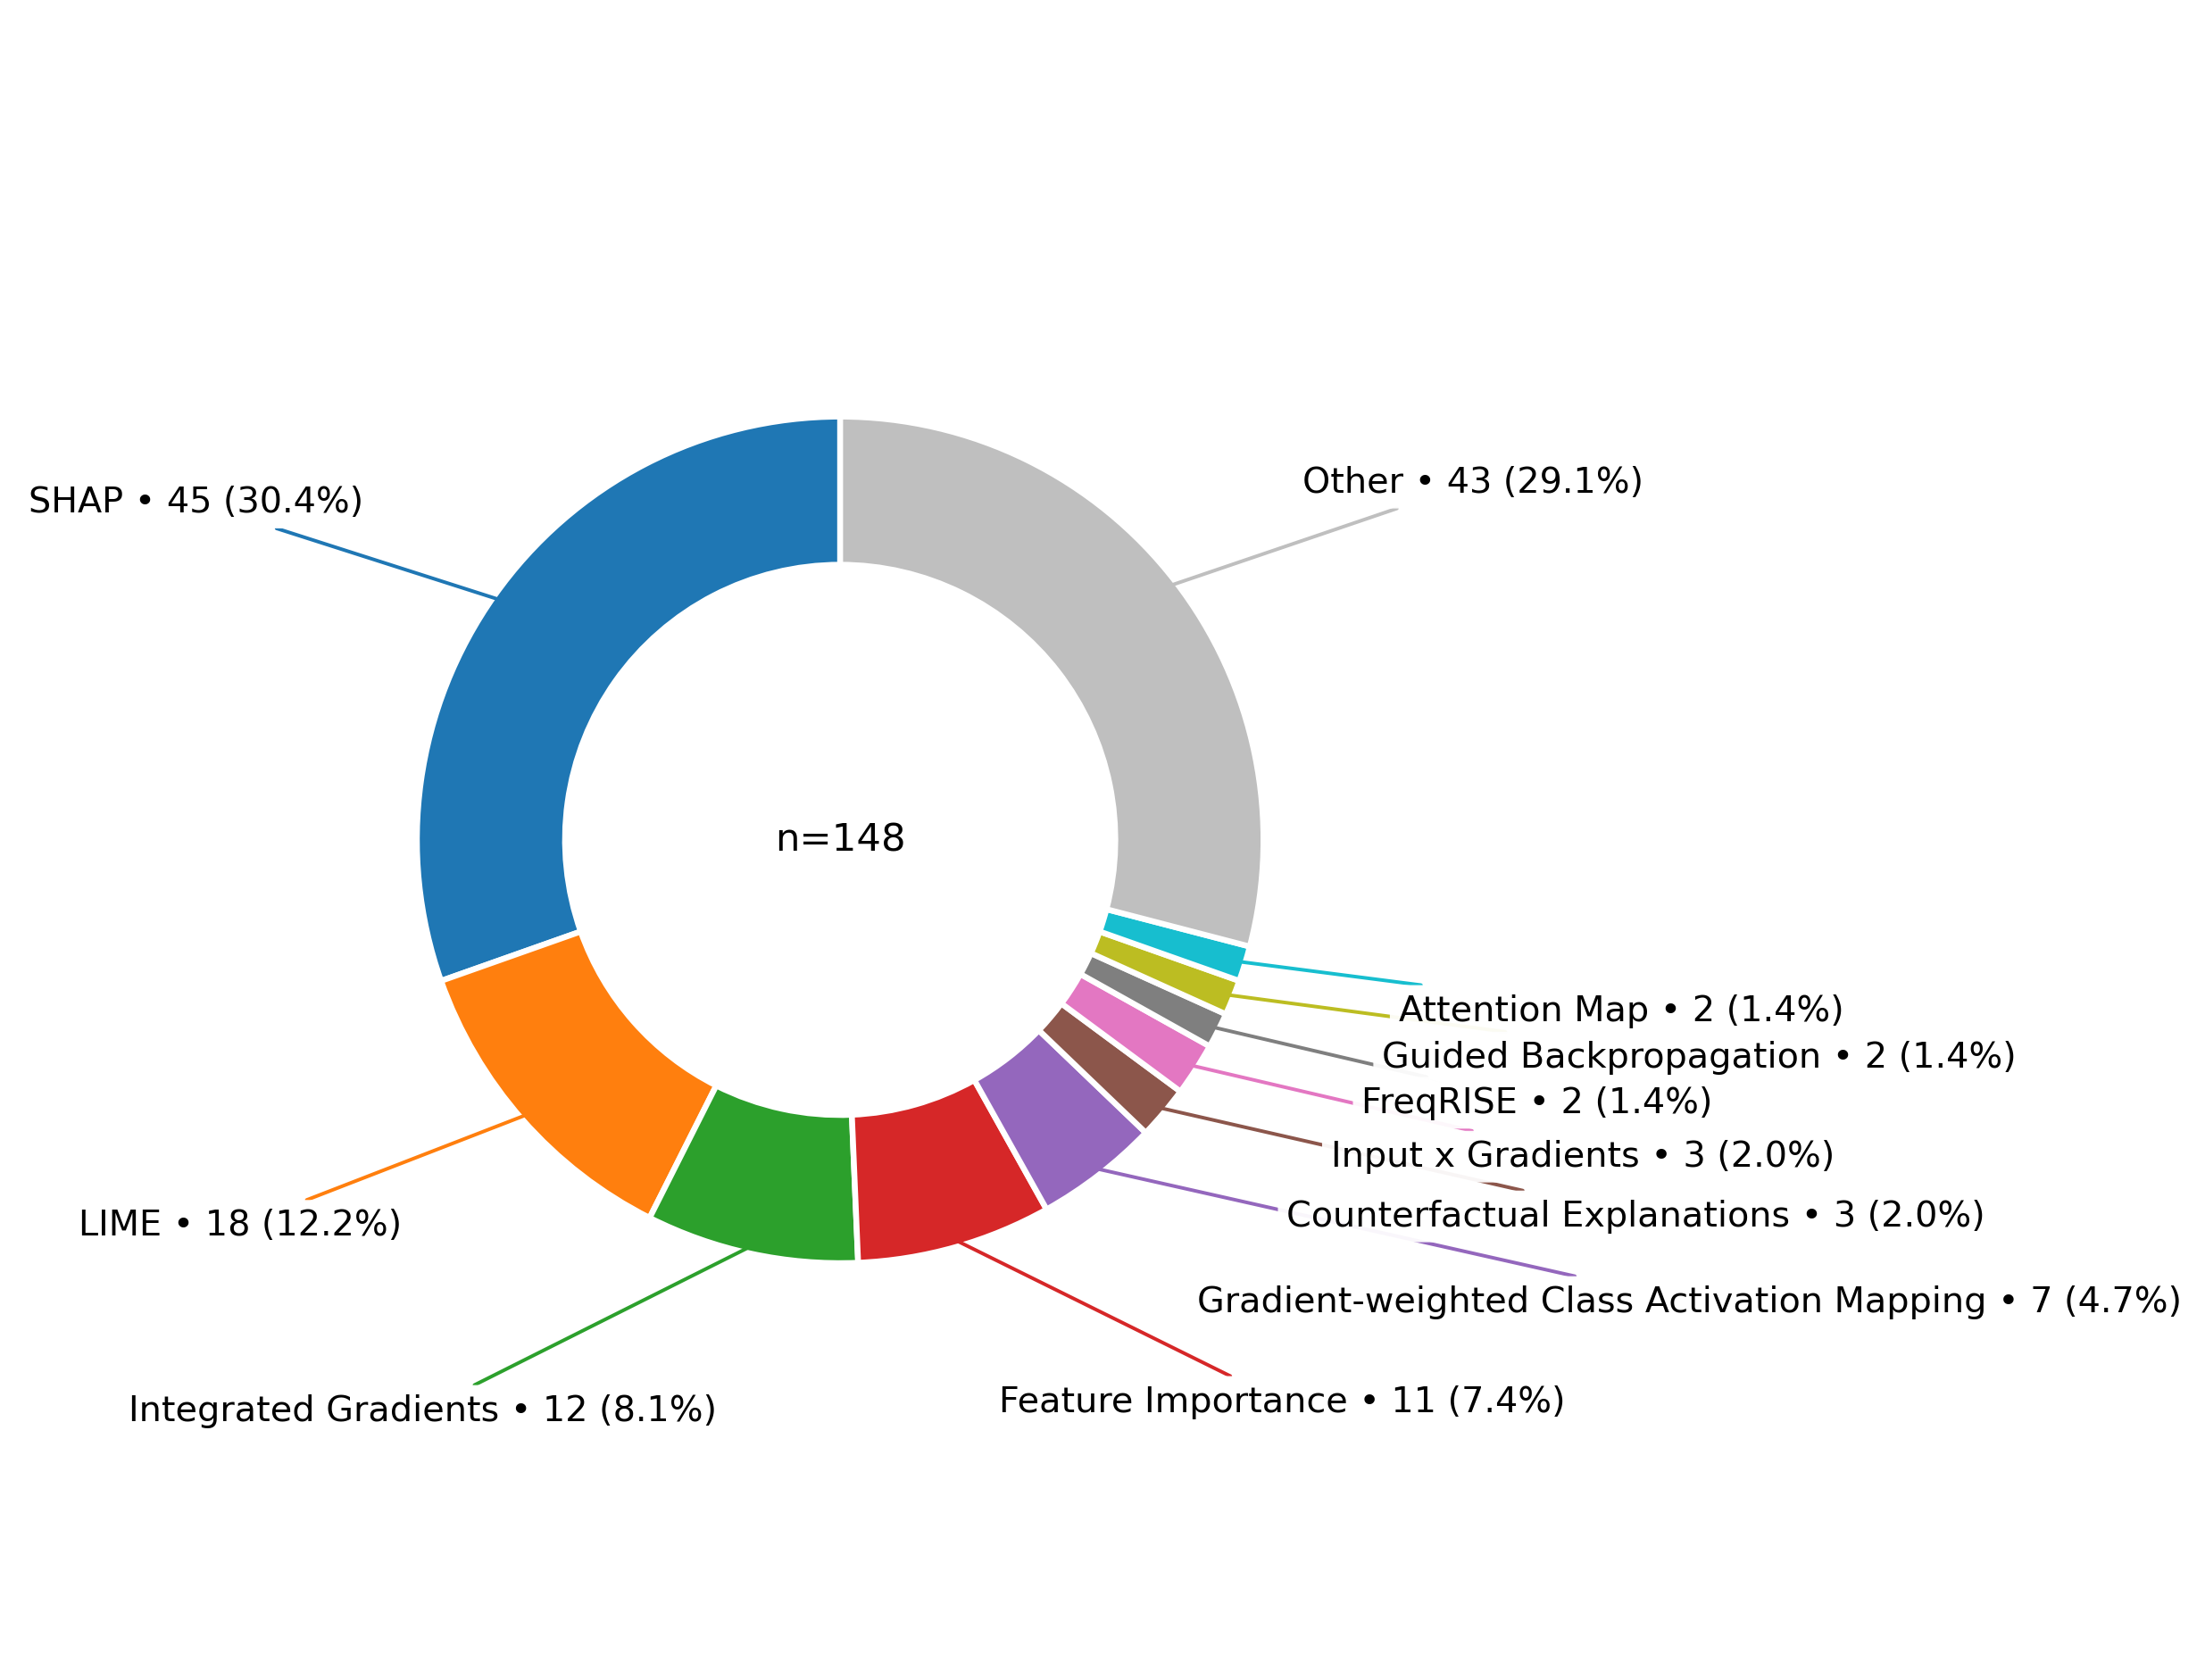

Saved to: xai_techniques_pie.png
                                            Count  Percent
XAI Technique(s)                                          
SHAP                                           45    30.41
LIME                                           18    12.16
Integrated Gradients                           12     8.11
Feature Importance                             11     7.43
Gradient-weighted Class Activation Mapping      7     4.73
Counterfactual Explanations                     3     2.03
Input x Gradients                               3     2.03
FreqRISE                                        2     1.35
Guided Backpropagation                          2     1.35
Attention Map                                   2     1.35
Other                                          43    29.05


In [23]:
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import cycle, islice
from datetime import datetime

# Config
PREFERRED_COLS = ["XAI Technique(s)"]  # tries in this order
MIN_PERCENT = 2.0    # (optional) group slices smaller than this % into "Other" AFTER top-k (set to 0 to disable)
TOP_K = 10           # show at most top-k categories; rest -> "Other"
SAVE_PATH = None


def _pick_categorical_column(df):
    # simple helper (uses preferred list, else first object/string col)
    for c in PREFERRED_COLS:
        if c in df.columns:
            return c
    for c in df.columns:
        if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]):
            return c
    raise ValueError("No suitable categorical column found.")


def pie_from_column_labeled(
    df,
    column=None,
    top_k=TOP_K,
    min_percent=MIN_PERCENT,
    save_path=SAVE_PATH,
    ring_width=0.35,
    label_radius=1.38,      # farther out = fewer collisions
    min_gap=0.085,          # larger vertical spacing between labels
    dpi_fig=260,
    dpi_save=450,
):
    if column is None:
        column = _pick_categorical_column(df)

    # clean
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()
    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    counts = s.value_counts().sort_values(ascending=False)

    # keep top-k, rest -> Other
    if top_k is not None and top_k > 0:
        counts_wo_other = counts.drop(labels=["Other"], errors="ignore")
        top = counts_wo_other.head(top_k)
        rest = counts_wo_other.iloc[top_k:]

        other_sum = int(rest.sum()) + int(counts.get("Other", 0))
        plot_counts = top.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum
    else:
        plot_counts = counts.copy()

    # optional: also collapse tiny slices into Other (after top-k)
    if min_percent and min_percent > 0 and len(plot_counts) > 1:
        total_plot_pre = plot_counts.sum()
        thresh = min_percent / 100.0

        # don't collapse "Other" itself in this pass
        non_other = plot_counts.drop(labels=["Other"], errors="ignore")
        small = non_other[non_other / total_plot_pre < thresh]
        big = non_other[non_other / total_plot_pre >= thresh]

        other_existing = int(plot_counts.get("Other", 0))
        other_sum = other_existing + int(small.sum())

        plot_counts = big.copy()
        if other_sum > 0:
            plot_counts.loc["Other"] = other_sum

    # stable order: keep counts order, ensure Other last
    if "Other" in plot_counts.index:
        non_other = plot_counts.drop("Other")
        plot_counts = pd.concat([non_other, plot_counts.loc[["Other"]]])

    labels = plot_counts.index.tolist()
    values = plot_counts.values
    total_plot = values.sum()

    # colors (Other -> gray)
    base_cycle = plt.rcParams.get("axes.prop_cycle", None)
    base_colors = base_cycle.by_key().get("color", []) if base_cycle else []
    if not base_colors:
        base_colors = [plt.cm.tab20(i) for i in range(20)]

    colors = list(islice(cycle(base_colors), len(labels)))
    for i, lab in enumerate(labels):
        if str(lab).strip().casefold() == "other":
            colors[i] = (0.75, 0.75, 0.75, 1.0)

    # plot donut
    fig, ax = plt.subplots(figsize=(9.5, 9.5), dpi=dpi_fig)
    wedges, _ = ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        wedgeprops={
            "linewidth": 1.8,
            "edgecolor": "white",
            "width": ring_width,
            "antialiased": True,
        },
    )
    ax.set_aspect("equal")

    # initial label targets
    info = []
    for w, lab, val, col in zip(wedges, labels, values, colors):
        ang = (w.theta2 + w.theta1) / 2.0
        rad = np.deg2rad(ang)
        x, y = np.cos(rad), np.sin(rad)
        info.append({
            "w": w,
            "lab": lab,
            "txt": f"{lab} • {val} ({val/total_plot*100:.1f}%)",
            "val": val,
            "col": col,
            "x": x,
            "y": y,
        })

    # distribute per side with bigger minimum gap
    def _spread(side, R, gap):
        side.sort(key=lambda d: d["y"])
        ys = [d["y"] * R for d in side]

        for i in range(1, len(ys)):
            if ys[i] - ys[i - 1] < gap:
                ys[i] = ys[i - 1] + gap

        if ys:
            offset = 0.0
            hi = R
            lo = -R
            if ys[-1] > hi:
                offset = hi - ys[-1]
            if ys[0] < lo:
                offset = max(offset, lo - ys[0])
            ys = [y + offset for y in ys]

        for d, yv in zip(side, ys):
            sgn = 1 if d["x"] >= 0 else -1
            d["y_lab"] = yv
            d["x_lab"] = sgn * np.sqrt(max(R**2 - yv**2, 1e-6))
            d["ha"] = "left" if sgn > 0 else "right"

    right = [d for d in info if d["x"] >= 0]
    left  = [d for d in info if d["x"] < 0]
    _spread(right, label_radius, min_gap)
    _spread(left,  label_radius, min_gap)

    # draw annotations
    extras = []
    r_outer = 1.0
    for d in info:
        x_end, y_end = 0.98 * r_outer * d["x"], 0.98 * r_outer * d["y"]
        ann = ax.annotate(
            d["txt"],
            xy=(x_end, y_end),
            xytext=(d["x_lab"], d["y_lab"]),
            ha=d["ha"],
            va="center",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.95),
            arrowprops=dict(arrowstyle="-", lw=1.1, color=d["col"], shrinkA=0, shrinkB=0),
        )
        extras.append(ann)

    # center total
    extras.append(ax.text(0, 0, f"n={total}", ha="center", va="center", fontsize=12))

    # spacious limits so labels never clip
    pad = 0.55
    lim = label_radius + pad
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.tight_layout()

    # autosave if not provided
    if not save_path:
        save_path = "xai_techniques_pie.png"

    fig.savefig(
        save_path,
        dpi=dpi_save,
        bbox_inches="tight",
        bbox_extra_artists=extras,
        pad_inches=0.6,
    )
    plt.show()

    summary = plot_counts.to_frame("Count")
    summary["Percent"] = (summary["Count"] / total_plot * 100).round(2)
    return summary, save_path


# run
summary, path = pie_from_column_labeled(
    df_xai,
    column="XAI Technique(s)",
    top_k=10,        # top10 + Other
    min_percent=0.0  # set to e.g. 2.0 if you ALSO want tiny slices merged into Other
)
print("Saved to:", path)
print(summary.head(15))


In [24]:
import pandas as pd
import re
import csv

def xai_technique_full_list_with_finance_split_refs(
    df,
    column="XAI Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || ",
):
    # Clean XAI technique column
    s = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    s = pd.Series(s, dtype="object").dropna()

    bad_strings = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    s = s[~s.str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings)]

    total = len(s)
    if total == 0:
        raise ValueError(f"No non-empty values in '{column}' after cleaning.")

    # Base count table
    table = s.value_counts().rename("Count").to_frame()
    table["Percent"] = (table["Count"] / total * 100).round(2)

    # Required columns
    for c in (field_col, author_col):
        if c not in df.columns:
            raise KeyError(f"df must contain '{c}'.")

    # Align cleaned columns with df rows
    tech_clean = df[column].map(lambda x: None if pd.isna(x) else str(x).strip())
    tech_clean = pd.Series(tech_clean, dtype="object")
    tech_clean = tech_clean.where(
        ~tech_clean.fillna("").str.replace(r"\s+", "", regex=True).str.casefold().isin(bad_strings),
        other=None
    )

    field_clean = df[field_col].map(lambda x: "" if pd.isna(x) else str(x).strip())
    is_finance = field_clean.str.casefold().eq(finance_label)

    authors_clean = df[author_col].map(lambda x: None if pd.isna(x) else str(x).strip())
    authors_clean = pd.Series(authors_clean, dtype="object").replace({"": None})

    # Finance counts per technique
    finance_counts = tech_clean[is_finance].dropna().value_counts()
    table["Finance Count"] = table.index.map(lambda t: int(finance_counts.get(t, 0)))
    table["Finance Share %"] = (table["Finance Count"] / table["Count"] * 100).round(2)

    # Split references
    fin_refs = {}
    nonfin_refs = {}

    for tech, is_fin, auth in zip(tech_clean, is_finance, authors_clean):
        if tech is None or auth is None:
            continue

        target = fin_refs if is_fin else nonfin_refs
        target.setdefault(tech, [])
        if auth not in target[tech]:
            target[tech].append(auth)

    table["Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(fin_refs.get(t, []))
    )
    table["Non-Financial References (Authors)"] = table.index.map(
        lambda t: ref_sep.join(nonfin_refs.get(t, []))
    )

    table.index.name = column
    return table.reset_index(), total


# run on df_xai (exploded XAI df)
xai_table, n_total_xai = xai_technique_full_list_with_finance_split_refs(
    df_xai,
    column="XAI Technique(s)",
    field_col="Field",
    author_col="Author",
    finance_label="finance",
    ref_sep=" || "
)

xai_table.to_csv(
    "xai_technique_finance_split_refs.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL
)

print(f"Total non-empty entries: n={n_total_xai}")
display(xai_table)


Total non-empty entries: n=148


,XAI Technique(s),Count,Percent,Finance Count,Finance Share %,Financial References (Authors),Non-Financial References (Authors)
0,SHAP,45,30.41,6,13.33,"Parente, M.; Rizzuti, L.; Trerotola, M. || Val...","Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D...."
1,LIME,18,12.16,5,27.78,"Valensky, D.; Mohaghegh, M. || Deng, S.; Zhu, ...","Mienye, E.; Jere, N.; Obaido, G.; Mienye, I.D...."
2,Integrated Gradients,12,8.11,1,8.33,"Freeborough, W.; van Zyl, T.","Nguyen, T.T.; Le Nguyen, T.; Ifrim, G. || Iqba..."
3,Feature Importance,11,7.43,5,45.45,"Park, H.J.; Kim, Y.; Kim, H.Y. || Valensky, D....","Doddaiah, R.; Parvatharaju, P.S.; Rundensteine..."
4,Gradient-weighted Class Activation Mapping,7,4.73,0,0.00,,"Kuo, C.-H.; Liu, G.-T.; Lee, C.-E.; Wu, J.; Ca..."
5,Counterfactual Explanations,3,2.03,0,0.00,,"Sweidan, J.; El-Yacoubi, M.A.; Rigaud, A.-S. |..."
6,Input x Gradients,3,2.03,0,0.00,,"Najjar, H.; Miranda, M.; Nuske, M.; Roscher, R..."
7,Layer-wise Relevance Propogation,2,1.35,0,0.00,,"Vielhaben, J.; Lapuschkin, S.; Montavon, G.; S..."
8,Saliency,2,1.35,0,0.00,,"Kuo, C.-H.; Liu, G.-T.; Lee, C.-E.; Wu, J.; Ca..."
9,Feature Ablation,2,1.35,0,0.00,,"Cao, Fanpu; Yang, Shu; Chen, Zhengjian; Liu, Y..."


In [25]:
df_xai_exp = df_xai.copy()

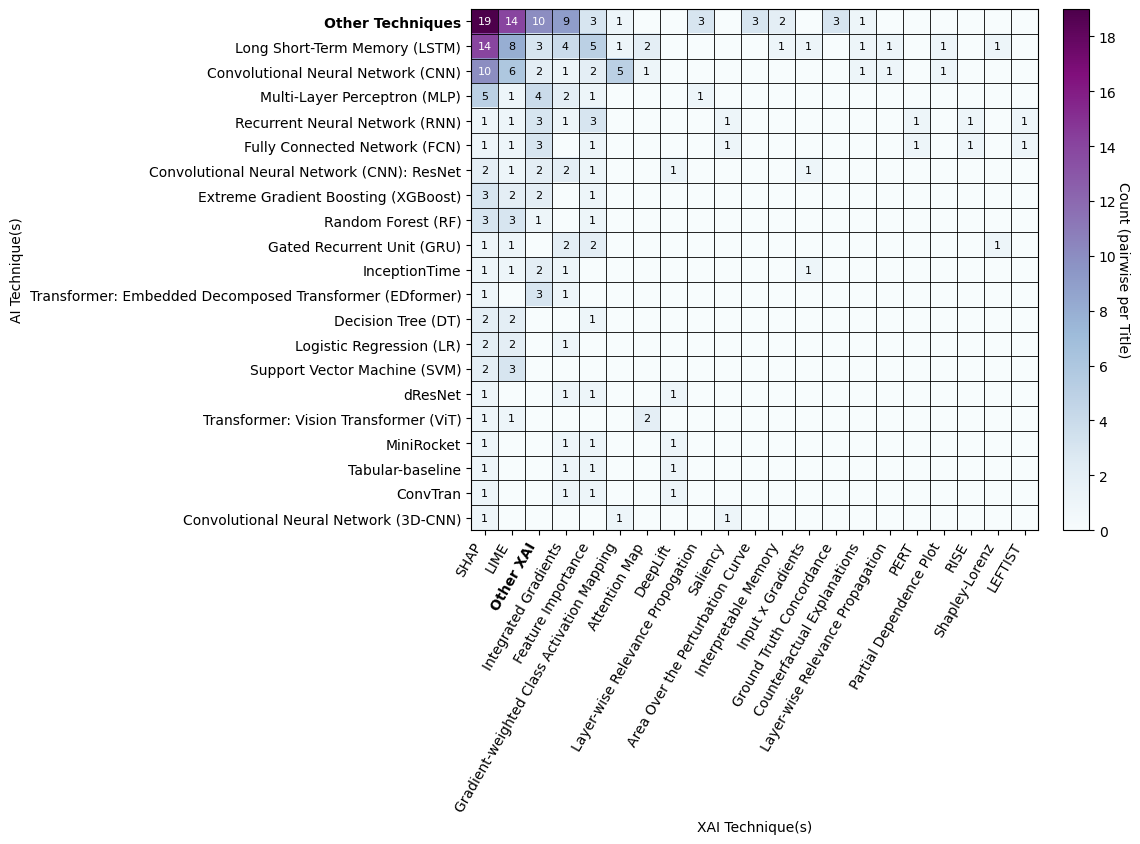

Saved: heatmap_ml_vs_xai_by_titlepairs.pdf


XAI,SHAP,LIME,Other XAI,Integrated Gradients,Feature Importance,Gradient-weighted Class Activation Mapping,Attention Map,DeepLift,Layer-wise Relevance Propogation,Saliency,...,Interpretable Memory,Input x Gradients,Ground Truth Concordance,Counterfactual Explanations,Layer-wise Relevance Propagation,PERT,Partial Dependence Plot,RISE,Shapley-Lorenz,LEFTIST
ML,,,,,,,,,,,,,,,,,,,,,
Other Techniques,19.0,14.0,10.0,9.0,3.0,1.0,0.0,0.0,3.0,0.0,...,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Long Short-Term Memory (LSTM),14.0,8.0,3.0,4.0,5.0,1.0,2.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
Convolutional Neural Network (CNN),10.0,6.0,2.0,1.0,2.0,5.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Multi-Layer Perceptron (MLP),5.0,1.0,4.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recurrent Neural Network (RNN),1.0,1.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Fully Connected Network (FCN),1.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Convolutional Neural Network (CNN): ResNet,2.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Extreme Gradient Boosting (XGBoost),3.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Random Forest (RF),3.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Heatmap: ML Techniques × XAI Techniques (pairwise within each Title)
# - Makes "Other Techniques" (row) and "Other XAI" (column) bold in tick labels
# Pure matplotlib (no seaborn).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
import re

# Config 
TOP_TECH = 20    # keep top-N ML techniques; others -> "Other Techniques" (None to disable)
TOP_XAI  = 20    # keep top-M XAI techniques; others -> "Other XAI" (None to disable)
ANNOTATE = True  # write integer counts in cells
ROT      = 60    # x-label rotation in degrees
CMAP     = plt.cm.BuPu

# Optional Title filtering
TITLE_EXACT  = None                 # e.g., "A Specific Paper" or ["Paper A","Paper B"]
TITLE_SUBSTR = None                 # e.g., "finance" or ["loan","credit"]

# Prep 
if "df_xai_exp" not in globals() or not isinstance(df_xai_exp, pd.DataFrame):
    raise NameError("df_xai_exp must be a pandas DataFrame in the current session.")

XAI_COL = "XAI Techniques Expanded" if "XAI Techniques Expanded" in df_xai_exp.columns else "XAI Technique(s)"
for c in ["Title_zotero", "ML Technique(s)", XAI_COL]:
    if c not in df_xai_exp.columns:
        raise KeyError(f"Missing column in df_xai_exp: {c}")

df = df_xai_exp.copy()
df["Title_zotero"]     = df["Title_zotero"].astype("string").str.strip().replace({"<NA>": ""}).fillna("")
df["ML Technique(s)"]  = df["ML Technique(s)"].astype("string").str.strip().replace({"<NA>": ""}).fillna("")
df[XAI_COL]            = df[XAI_COL].astype("string").str.strip().replace({"<NA>": ""}).fillna("")

# Title filters
if TITLE_EXACT is not None:
    if isinstance(TITLE_EXACT, str):
        TITLE_EXACT = [TITLE_EXACT]
    df = df[df["Title_zotero"].isin(TITLE_EXACT)]

if TITLE_SUBSTR is not None:
    if isinstance(TITLE_SUBSTR, str):
        TITLE_SUBSTR = [TITLE_SUBSTR]
    pats = [re.compile(re.escape(s), flags=re.I) for s in TITLE_SUBSTR]
    df = df[df["Title_zotero"].apply(lambda t: any(p.search(t or "") for p in pats))]

# Keep rows with all fields
df = df[(df["Title_zotero"] != "") & (df["ML Technique(s)"] != "") & (df[XAI_COL] != "")]
if df.empty:
    raise ValueError("No rows after cleaning/filters. Check 'Title_zotero', 'ML Technique(s)', and XAI column.")

# Build pairwise counts per Title
def _split_list(s):
    s = (s or "").strip()
    if not s:
        return []
    parts = [p.strip() for p in s.split(",")]
    # de-dup while preserving order
    seen, out = set(), []
    for p in parts:
        k = p.lower()
        if p and k not in seen:
            seen.add(k)
            out.append(p)
    return out

def _dedup(seq):
    seen, out = set(), []
    for p in seq:
        k = p.lower()
        if p and k not in seen:
            seen.add(k)
            out.append(p)
    return out

edges = []
for title, sub in df.groupby("Title_zotero"):
    mls, xais = [], []
    for _, r in sub.iterrows():
        mls.extend(_split_list(r["ML Technique(s)"]))
        xais.extend(_split_list(r[XAI_COL]))
    mls  = _dedup(mls)
    xais = _dedup(xais)
    if not mls or not xais:
        continue
    edges.extend([(m, x, 1.0) for m in mls for x in xais])

edges_df = pd.DataFrame(edges, columns=["ML", "XAI", "w"])
if edges_df.empty:
    raise ValueError("No ML↔XAI pairs were formed. Do the selected titles contain both fields?")

flows = edges_df.groupby(["ML", "XAI"])["w"].sum().unstack(fill_value=0)

# Optional top-N caps
OTHER_TECH_LABEL = "Other Techniques"
OTHER_XAI_LABEL  = "Other XAI"

# rows (ML)
if TOP_TECH is not None and len(flows.index) > TOP_TECH:
    tech_tot = flows.sum(axis=1).sort_values(ascending=False)
    keep = tech_tot.index[:TOP_TECH]
    other_row = flows.loc[~flows.index.isin(keep)].sum(axis=0)
    flows = flows.loc[flows.index.isin(keep)]
    if other_row.sum() > 0:
        flows.loc[OTHER_TECH_LABEL] = other_row

# cols (XAI)
if TOP_XAI is not None and len(flows.columns) > TOP_XAI:
    xai_tot = flows.sum(axis=0).sort_values(ascending=False)
    keep = xai_tot.index[:TOP_XAI]
    other_col = flows.loc[:, ~flows.columns.isin(keep)].sum(axis=1)
    flows = flows.loc[:, flows.columns.isin(keep)]
    if other_col.sum() > 0:
        flows[OTHER_XAI_LABEL] = other_col

# Reorder by totals for readability
flows = flows.loc[
    flows.sum(axis=1).sort_values(ascending=False).index,
    flows.sum(axis=0).sort_values(ascending=False).index
]

# Plot
n_rows, n_cols = flows.shape
fig_w = max(8, min(22, 2 + 0.45 * n_cols))
fig_h = max(4.5, min(18, 1.2 + 0.35 * n_rows))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(
    flows.values,
    aspect="auto",
    interpolation="nearest",
    cmap=CMAP,
    vmin=0,
    vmax=max(1, flows.values.max())
)

# ticks & labels
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(list(flows.columns), rotation=ROT, ha="right")
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(list(flows.index))

# Make "Other ..." tick labels bold
for t in ax.get_xticklabels():
    if t.get_text() == OTHER_XAI_LABEL:
        t.set_fontweight("bold")

for t in ax.get_yticklabels():
    if t.get_text() == OTHER_TECH_LABEL:
        t.set_fontweight("bold")

# subtle gridlines
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color=(0, 0, 0, 0.06), linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# annotations
if ANNOTATE:
    vmax = max(1, flows.values.max())
    for i in range(n_rows):
        for j in range(n_cols):
            v = int(flows.iat[i, j])
            if v > 0:
                ax.text(
                    j, i, str(v),
                    ha="center", va="center",
                    fontsize=8,
                    color=("white" if (v / vmax) > 0.5 else "black")
                )

# colorbar with integer ticks
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Count (pairwise per Title)", rotation=270, labelpad=10)
cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.set_xlabel("XAI Technique(s)")
ax.set_ylabel("AI Technique(s)")

plt.tight_layout()
out_path = "heatmap_ml_vs_xai_by_titlepairs.pdf"
plt.savefig(out_path, dpi=400, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# Optional: get the table back
flows

In [27]:
# Underlying heatmap tables

# 1) Matrix form: same shape as the heatmap
table_heatmap_matrix = flows.copy()
table_heatmap_matrix.index.name = "ML Technique"
table_heatmap_matrix.columns.name = "XAI Technique"

# 2) Long form: one row per non-zero ML-XAI pair
table_heatmap_long = (
    flows
    .stack()
    .reset_index()
    .rename(columns={
        "ML": "ML Technique",
        "XAI": "XAI Technique",
        0: "Count"
    })
)

# In case index/column names are not ML/XAI after reordering:
table_heatmap_long.columns = ["ML Technique", "XAI Technique", "Count"]
table_heatmap_long = table_heatmap_long[table_heatmap_long["Count"] > 0]
table_heatmap_long["Count"] = table_heatmap_long["Count"].astype(int)

# 3) Row totals: ML technique totals
table_ml_totals = (
    flows.sum(axis=1)
    .sort_values(ascending=False)
    .reset_index()
)
table_ml_totals.columns = ["ML Technique", "Total Count"]

# 4) Column totals: XAI technique totals
table_xai_totals = (
    flows.sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)
table_xai_totals.columns = ["XAI Technique", "Total Count"]

# Display
print("Heatmap matrix")
display(table_heatmap_matrix)

print("Heatmap long table")
display(table_heatmap_long)

print("ML technique totals")
display(table_ml_totals)

print("XAI technique totals")
display(table_xai_totals)

# Optional: save to Excel
xlsx_path = "heatmap_ml_vs_xai_underlying_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    table_heatmap_matrix.to_excel(writer, sheet_name="Heatmap_Matrix")
    table_heatmap_long.to_excel(writer, sheet_name="Heatmap_Long", index=False)
    table_ml_totals.to_excel(writer, sheet_name="ML_Totals", index=False)
    table_xai_totals.to_excel(writer, sheet_name="XAI_Totals", index=False)

print(f"Saved: {xlsx_path}")

Heatmap matrix


XAI Technique,SHAP,LIME,Other XAI,Integrated Gradients,Feature Importance,Gradient-weighted Class Activation Mapping,Attention Map,DeepLift,Layer-wise Relevance Propogation,Saliency,...,Interpretable Memory,Input x Gradients,Ground Truth Concordance,Counterfactual Explanations,Layer-wise Relevance Propagation,PERT,Partial Dependence Plot,RISE,Shapley-Lorenz,LEFTIST
ML Technique,,,,,,,,,,,,,,,,,,,,,
Other Techniques,19.0,14.0,10.0,9.0,3.0,1.0,0.0,0.0,3.0,0.0,...,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Long Short-Term Memory (LSTM),14.0,8.0,3.0,4.0,5.0,1.0,2.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
Convolutional Neural Network (CNN),10.0,6.0,2.0,1.0,2.0,5.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Multi-Layer Perceptron (MLP),5.0,1.0,4.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recurrent Neural Network (RNN),1.0,1.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Fully Connected Network (FCN),1.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
Convolutional Neural Network (CNN): ResNet,2.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Extreme Gradient Boosting (XGBoost),3.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Random Forest (RF),3.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Heatmap long table


,ML Technique,XAI Technique,Count
0,Other Techniques,SHAP,19
1,Other Techniques,LIME,14
2,Other Techniques,Other XAI,10
3,Other Techniques,Integrated Gradients,9
4,Other Techniques,Feature Importance,3
...,...,...,...
403,ConvTran,Feature Importance,1
406,ConvTran,DeepLift,1
420,Convolutional Neural Network (3D-CNN),SHAP,1
425,Convolutional Neural Network (3D-CNN),Gradient-weighted Class Activation Mapping,1


ML technique totals


,ML Technique,Total Count
0,Other Techniques,68.0
1,Long Short-Term Memory (LSTM),43.0
2,Convolutional Neural Network (CNN),30.0
3,Multi-Layer Perceptron (MLP),14.0
4,Recurrent Neural Network (RNN),13.0
5,Fully Connected Network (FCN),10.0
6,Convolutional Neural Network (CNN): ResNet,10.0
7,Extreme Gradient Boosting (XGBoost),8.0
8,Random Forest (RF),8.0
9,Gated Recurrent Unit (GRU),7.0


XAI technique totals


,XAI Technique,Total Count
0,SHAP,73.0
1,LIME,47.0
2,Other XAI,35.0
3,Integrated Gradients,28.0
4,Feature Importance,25.0
5,Gradient-weighted Class Activation Mapping,8.0
6,Attention Map,5.0
7,DeepLift,5.0
8,Layer-wise Relevance Propogation,4.0
9,Input x Gradients,3.0


Saved: heatmap_ml_vs_xai_underlying_tables.xlsx


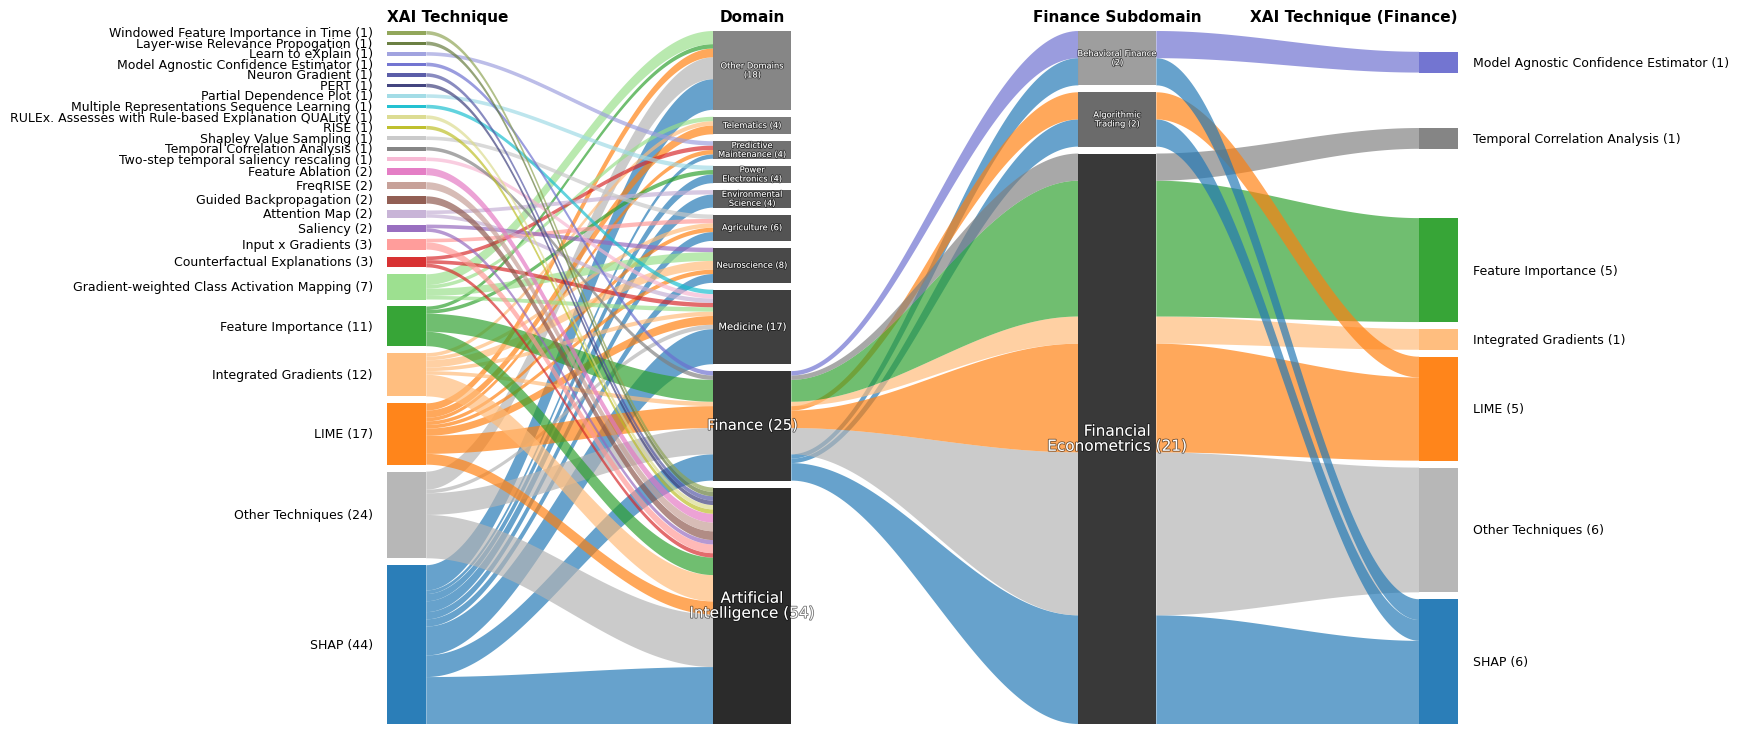

Saved: sankey_xai_domain_subdomain_xai_topdom.png


In [28]:
# Sankey: XAI Technique (ALL) → Domain (ALL) → Finance Subdomain → XAI Technique (Finance-only)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib import patheffects as pe
from datetime import datetime
import textwrap

# Config
TOP_TECH = 25
TOP_DOM  = 9
TOP_SPEC = 20

OTHER_TECH_LABEL = "Other Techniques"
OTHER_DOM_LABEL  = "Other Domains"
OTHER_SPEC_LABEL = "Other Finance"

BAR_W = 0.032
GAP = 0.01
LEFT_PAD, RIGHT_PAD = 0.012, 0.012
ALPHA_RIBBON, ALPHA_BAR = 0.68, 0.95

# Label rendering inside bars
DOMAIN_WRAP_CHARS = 16
SPEC_WRAP_CHARS   = 18
MIN_FONT_SIZE     = 6
MAX_FONT_SIZE     = 11
MIN_HEIGHT_FOR_TEXT = 0.018

# Safety checks
if "df_xai_exp" not in globals() or not isinstance(df_xai_exp, pd.DataFrame):
    raise NameError("df_xai_exp must be a pandas DataFrame in the current session.")

XAI_COL = "XAI Techniques Expanded" if "XAI Techniques Expanded" in df_xai_exp.columns else "XAI Technique(s)"
DOMAIN_COL = "Domain"
SPEC_COL = "Specific Domain (Finance only)"
FIN_LABEL = "Finance"

for c in [XAI_COL, DOMAIN_COL]:
    if c not in df_xai_exp.columns:
        raise KeyError(f"Missing required column: {c}")

# Prep / Clean
df_all = df_xai_exp.copy()

def _clean_col(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"<NA>": "", "<na>": "", "nan": "", "NaN": ""})
    return s.fillna("")

df_all[XAI_COL] = _clean_col(df_all[XAI_COL])
df_all[DOMAIN_COL] = _clean_col(df_all[DOMAIN_COL])
df_all[SPEC_COL] = _clean_col(df_all[SPEC_COL]) if SPEC_COL in df_all.columns else ""

df_all = df_all[(df_all[XAI_COL] != "") & (df_all[DOMAIN_COL] != "")]
if df_all.empty:
    raise ValueError(f"No rows with non-empty '{XAI_COL}' and '{DOMAIN_COL}'.")

# Finance-only subset
df_fin = df_all[df_all[DOMAIN_COL].str.casefold().eq(FIN_LABEL.casefold())].copy()
if df_fin.empty:
    raise ValueError("No Finance rows found. Sankey requires finance rows for the right legs.")
df_fin["__Spec"] = np.where(df_fin[SPEC_COL] != "", df_fin[SPEC_COL], "Finance (Unspecified)")

# Reduce cardinality
# Techniques
tech_tot_all = df_all.groupby(XAI_COL).size().sort_values(ascending=False)
tech_keep = tech_tot_all.index[:TOP_TECH].tolist() if len(tech_tot_all) > TOP_TECH else tech_tot_all.index.tolist()
df_all["__TechRed"] = np.where(df_all[XAI_COL].isin(tech_keep), df_all[XAI_COL], OTHER_TECH_LABEL)
df_fin["__TechRed"] = np.where(df_fin[XAI_COL].isin(tech_keep), df_fin[XAI_COL], OTHER_TECH_LABEL)

# Domains (TOP 9 + Other)
dom_tot_all = df_all.groupby(DOMAIN_COL).size().sort_values(ascending=False)
dom_keep = dom_tot_all.index[:TOP_DOM].tolist() if len(dom_tot_all) > TOP_DOM else dom_tot_all.index.tolist()
df_all["__DomRed"] = np.where(df_all[DOMAIN_COL].isin(dom_keep), df_all[DOMAIN_COL], OTHER_DOM_LABEL)
df_fin["__DomRed"] = np.where(df_fin[DOMAIN_COL].isin(dom_keep), df_fin[DOMAIN_COL], OTHER_DOM_LABEL)

# Finance subdomains
spec_tot_all_fin = df_fin.groupby("__Spec").size().sort_values(ascending=False)
spec_keep = spec_tot_all_fin.index[:TOP_SPEC].tolist() if len(spec_tot_all_fin) > TOP_SPEC else spec_tot_all_fin.index.tolist()
df_fin["__SpecRed"] = np.where(df_fin["__Spec"].isin(spec_keep), df_fin["__Spec"], OTHER_SPEC_LABEL)

# Flow tables
flows_T_D = df_all.groupby(["__TechRed", "__DomRed"]).size().unstack(fill_value=0)
flows_T_S_fin = df_fin.groupby(["__TechRed", "__SpecRed"]).size().unstack(fill_value=0)

# Node totals & orders
tech_tot_left = flows_T_D.sum(axis=1).sort_values(ascending=False)
dom_totals    = flows_T_D.sum(axis=0).sort_values(ascending=False)

# order: keep "Other Domains" last
dom_order = dom_totals.index.tolist()
if OTHER_DOM_LABEL in dom_order:
    dom_order = [d for d in dom_order if d != OTHER_DOM_LABEL] + [OTHER_DOM_LABEL]
flows_T_D = flows_T_D.reindex(index=tech_tot_left.index, columns=dom_order, fill_value=0)

spec_totals = flows_T_S_fin.sum(axis=0).sort_values(ascending=False)

# order: keep "Other Finance" last
spec_order = spec_totals.index.tolist()
if OTHER_SPEC_LABEL in spec_order:
    spec_order = [s for s in spec_order if s != OTHER_SPEC_LABEL] + [OTHER_SPEC_LABEL]
flows_T_S_fin = flows_T_S_fin.reindex(index=tech_tot_left.index, columns=spec_order, fill_value=0)

# right-tech totals align to ALL-tech order
tech_tot_right = flows_T_S_fin.sum(axis=1).reindex(tech_tot_left.index, fill_value=0)

tech_labels = tech_tot_left.index.tolist()
dom_labels  = flows_T_D.columns.tolist()
spec_labels = flows_T_S_fin.columns.tolist()
tech_right_labels = tech_labels[:]  # same order on the right

# Colors
def make_color_map(labels):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])
    if len(colors) < len(labels):
        need = len(labels) - len(colors)
        hsv = plt.get_cmap("hsv", need + 1)
        colors.extend([hsv(i) for i in range(need)])
    mapping = {lab: colors[i] for i, lab in enumerate(labels)}
    if OTHER_TECH_LABEL in mapping:
        mapping[OTHER_TECH_LABEL] = (0.7, 0.7, 0.7, 1.0)
    return mapping

color_by_tech = make_color_map(tech_labels)

def greyscale_list(n, lo=0.12, hi=0.55):
    if n <= 0:
        return []
    vals = np.linspace(lo, hi, n)
    return [(v, v, v, 1.0) for v in vals]

domain_colors = {d: c for d, c in zip(dom_labels, greyscale_list(len(dom_labels), lo=0.12, hi=0.50))}
spec_colors   = {s: c for s, c in zip(spec_labels, greyscale_list(len(spec_labels), lo=0.18, hi=0.60))}

# Layout helpers
def stack_positions(values, total_height=1.0, gap=GAP):
    vals = np.asarray(values, dtype=float)
    s = vals.sum()
    usable = max(total_height - gap * max(len(vals) - 1, 0), 0.0)
    heights = np.zeros_like(vals) if s <= 0 else (vals / s) * usable
    y0, y = [], 0.0
    for h in heights:
        y0.append(y)
        y += h + gap
    y0 = np.array(y0)
    y1 = y0 + heights
    return y0, y1, heights

def cubic_bezier(P0, P1, P2, P3, ts):
    ts = np.asarray(ts)[:, None]
    return ((1-ts)**3)*P0 + 3*((1-ts)**2)*ts*P1 + 3*(1-ts)*(ts**2)*P2 + (ts**3)*P3

def draw_ribbon(ax, x0, y0_top, y0_bot, x1, y1_top, y1_bot, color, curvature=0.35, n=100, alpha=ALPHA_RIBBON):
    P0 = np.array([x0, y0_top]);  P3 = np.array([x1, y1_top]);  dx = x1 - x0
    P1 = P0 + np.array([dx*curvature, 0.0]);  P2 = P3 - np.array([dx*curvature, 0.0])
    ts = np.linspace(0, 1, n)
    top = cubic_bezier(P0, P1, P2, P3, ts)

    P0b = np.array([x0, y0_bot]);  P3b = np.array([x1, y1_bot])
    P1b = P0b + np.array([dx*curvature, 0.0]);  P2b = P3b - np.array([dx*curvature, 0.0])
    bot = cubic_bezier(P0b, P1b, P2b, P3b, ts)

    verts = np.vstack([top, bot[::-1], top[:1]])
    codes = [Path.MOVETO] + [Path.LINETO]*(top.shape[0]-1) + [Path.LINETO]*bot.shape[0] + [Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts, codes), lw=0, facecolor=color, alpha=alpha))

# Label bars: max 2 lines, adaptive wrap, ellipsis if too long
def draw_labeled_bar(ax, x_left, y0, height, width, facecolor, label, wrap_chars=14):
    if height <= 0:
        return

    ax.add_patch(Rectangle((x_left, y0), width, height, lw=0,
                           facecolor=facecolor, alpha=ALPHA_BAR))

    if height < MIN_HEIGHT_FOR_TEXT or not label:
        return

    base = max(8, int(round(wrap_chars * (width / (2 * BAR_W)))))
    wrap = int(np.clip(base, 8, 26))

    lines = textwrap.wrap(label, width=wrap) or [label]
    if len(lines) > 2:
        lines = lines[:2]
        if len(lines[1]) >= 2:
            lines[1] = lines[1][:-1] + "…"

    txt = "\n".join(lines)

    fs = (height * 120) / (len(lines) + 0.8)
    fs = float(np.clip(fs, MIN_FONT_SIZE, MAX_FONT_SIZE))

    t = ax.text(
        x_left + width/2, y0 + height/2, txt,
        ha="center", va="center", fontsize=fs, color="white",
        clip_on=True, linespacing=1.0
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground=(0, 0, 0, 0.55))])

# Domain label formatting (FORCE AI to show fully with count)
def domain_label_text(dom: str, count: int) -> str:
    dom_str = str(dom)
    if dom_str == "Artificial Intelligence":
        # forced break ensures "(n)" stays visible and no truncation occurs
        return f"Artificial\nIntelligence ({count})"
    return f"{dom_str} ({count})"

# Positions
x0, x1, x2, x3 = 0.06, 0.36, 0.66, 0.94

yl0, yl1, hl = stack_positions(tech_tot_left.values)
ym0, ym1, hm = stack_positions(flows_T_D.sum(axis=0).values)
ys0, ys1, hs = stack_positions(spec_totals.values)
yr0, yr1, hr = stack_positions(tech_tot_right.values)

# Slices for ribbons 
slice_TD_left, slice_TD_right = {}, {}

for i, tech in enumerate(tech_labels):
    total_i, y = tech_tot_left.values[i], yl0[i]
    if total_i <= 0:
        continue
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_i == 0 else (f / total_i) * hl[i]
        slice_TD_left[(tech, dom)] = (y + h, y)
        y += h

for j, dom in enumerate(dom_labels):
    total_j, y = flows_T_D[dom].sum(), ym0[j]
    if total_j <= 0:
        continue
    for tech in tech_labels:
        f = flows_T_D.loc[tech, dom]
        h = 0.0 if total_j == 0 else (f / total_j) * hm[j]
        slice_TD_right[(tech, dom)] = (y + h, y)
        y += h

slice_FS_left, slice_FS_right = {}, {}
slice_ST_left, slice_ST_right = {}, {}

if FIN_LABEL in dom_labels:
    # B left: Finance segment split by subdomain
    for tech in tech_labels:
        seg = slice_TD_right.get((tech, FIN_LABEL))
        tech_fin_total = flows_T_D.loc[tech, FIN_LABEL] if FIN_LABEL in flows_T_D.columns else 0
        if (not seg) or tech_fin_total <= 0:
            continue
        seg_top, seg_bot = seg
        seg_h = seg_top - seg_bot
        y = seg_bot
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * seg_h
            slice_FS_left[(tech, spec)] = (y + h, y)
            y += h

    # B right: stack incoming techniques for each subdomain
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_FS_right[(tech, spec)] = (y + h, y)
            y += h

    # C left/right: subdomain -> right-tech
    for k, spec in enumerate(spec_labels):
        spec_total, y = spec_totals.loc[spec], ys0[k]
        if spec_total <= 0:
            continue
        for tech in tech_right_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if spec_total == 0 else (f / spec_total) * hs[k]
            slice_ST_left[(spec, tech)] = (y + h, y)
            y += h

    for i, tech in enumerate(tech_right_labels):
        tech_fin_total, y = tech_tot_right.loc[tech], yr0[i]
        if tech_fin_total <= 0:
            continue
        for spec in spec_labels:
            f = flows_T_S_fin.loc[tech, spec]
            h = 0.0 if tech_fin_total == 0 else (f / tech_fin_total) * hr[i]
            slice_ST_right[(spec, tech)] = (y + h, y)
            y += h

# Plot
fig, ax = plt.subplots(figsize=(15.7, 9.0))
for s in ax.spines.values():
    s.set_visible(False)
ax.set_axis_off()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# A) Technique → Domain (ALL)
for tech in tech_labels:
    col = color_by_tech[tech]
    for dom in dom_labels:
        f = flows_T_D.loc[tech, dom]
        if f <= 0:
            continue
        yL_top, yL_bot = slice_TD_left[(tech, dom)]
        yR_top, yR_bot = slice_TD_right[(tech, dom)]
        draw_ribbon(ax, x0 + BAR_W, yL_top, yL_bot, x1 - BAR_W, yR_top, yR_bot, color=col)

# B) Finance → Subdomain
if FIN_LABEL in dom_labels:
    for tech in tech_labels:
        for spec in spec_labels:
            key = (tech, spec)
            if key not in slice_FS_left or key not in slice_FS_right:
                continue
            yL_top, yL_bot = slice_FS_left[key]
            yR_top, yR_bot = slice_FS_right[key]
            draw_ribbon(ax, x1 + BAR_W, yL_top, yL_bot, x2 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# C) Subdomain → Technique (right)
for spec in spec_labels:
    for tech in tech_right_labels:
        key = (spec, tech)
        if key not in slice_ST_left or key not in slice_ST_right:
            continue
        yL_top, yL_bot = slice_ST_left[key]
        yR_top, yR_bot = slice_ST_right[key]
        draw_ribbon(ax, x2 + BAR_W, yL_top, yL_bot, x3 - BAR_W, yR_top, yR_bot, color=color_by_tech[tech])

# Bars: Left techniques
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.add_patch(Rectangle((x0, yl0[i]), BAR_W, hl[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Bars: Domains (TOP 9 + Other) with AI label forced
for j, dom in enumerate(dom_labels):
    if hm[j] <= 0:
        continue
    count_dom = int(flows_T_D[dom].sum())
    draw_labeled_bar(
        ax,
        x_left=(x1 - BAR_W),
        y0=ym0[j],
        height=hm[j],
        width=2*BAR_W,
        facecolor=domain_colors[dom],
        label=domain_label_text(dom, count_dom),
        wrap_chars=22 if str(dom) == "Artificial Intelligence" else DOMAIN_WRAP_CHARS
    )

# Bars: Finance subdomains
for k, spec in enumerate(spec_labels):
    if hs[k] <= 0:
        continue
    draw_labeled_bar(
        ax,
        x_left=(x2 - BAR_W),
        y0=ys0[k],
        height=hs[k],
        width=2*BAR_W,
        facecolor=spec_colors[spec],
        label=f"{spec} ({int(spec_totals.loc[spec])})",
        wrap_chars=SPEC_WRAP_CHARS
    )

# Bars: Right techniques (touch ribbons)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.add_patch(Rectangle((x3 - BAR_W, yr0[i]), BAR_W, hr[i], lw=0,
                               facecolor=color_by_tech[tech], alpha=ALPHA_BAR))

# Left technique labels
for i, tech in enumerate(tech_labels):
    if hl[i] > 0:
        ax.text(x0 - LEFT_PAD, (yl0[i] + yl1[i]) / 2, f"{tech} ({int(tech_tot_left.loc[tech])})",
                ha="right", va="center", fontsize=9, clip_on=False)

# Right technique labels (skip zeros to reduce clutter)
for i, tech in enumerate(tech_right_labels):
    if hr[i] > 0:
        ax.text(x3 + RIGHT_PAD, (yr0[i] + yr1[i]) / 2, f"{tech} ({int(tech_tot_right.loc[tech])})",
                ha="left", va="center", fontsize=9, clip_on=False)

# Column titles
ax.text(x0, 1.01, "XAI Technique",           ha="left",   va="bottom", fontsize=11, weight="bold")
ax.text(x1, 1.01, "Domain",                  ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x2, 1.01, "Finance Subdomain",       ha="center", va="bottom", fontsize=11, weight="bold")
ax.text(x3, 1.01, "XAI Technique (Finance)", ha="right",  va="bottom", fontsize=11, weight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()

png_path = f"sankey_xai_domain_subdomain_xai_topdom.png"
fig.savefig(png_path, dpi=1000, bbox_inches="tight")
print(f"Saved: {png_path}")


In [29]:
# Underlying Sankey tables

# 1) XAI Technique (ALL) -> Domain (ALL)
table_xai_domain = (
    flows_T_D
    .stack()
    .reset_index()
    .rename(columns={
        "__TechRed": "XAI Technique",
        "__DomRed": "Domain",
        0: "Count"
    })
)
table_xai_domain = table_xai_domain[table_xai_domain["Count"] > 0]

# 2) Finance-only XAI Technique -> Finance Subdomain
table_xai_subdomain_fin = (
    flows_T_S_fin
    .stack()
    .reset_index()
    .rename(columns={
        "__TechRed": "XAI Technique",
        "__SpecRed": "Finance Subdomain",
        0: "Count"
    })
)
table_xai_subdomain_fin = table_xai_subdomain_fin[table_xai_subdomain_fin["Count"] > 0]

# 3) Full Finance path:
# XAI Technique (ALL reduced) -> Finance -> Finance Subdomain -> XAI Technique (Finance-only)
table_finance_path = table_xai_subdomain_fin.copy()
table_finance_path.insert(1, "Domain", FIN_LABEL)
table_finance_path["XAI Technique (Finance-only)"] = table_finance_path["XAI Technique"]

# 4) Node totals
table_nodes = pd.concat([
    tech_tot_left.rename("Count").reset_index()
        .rename(columns={"index": "Node"})
        .assign(Level="XAI Technique"),

    dom_totals.rename("Count").reset_index()
        .rename(columns={"index": "Node"})
        .assign(Level="Domain"),

    spec_totals.rename("Count").reset_index()
        .rename(columns={"index": "Node"})
        .assign(Level="Finance Subdomain"),

    tech_tot_right.rename("Count").reset_index()
        .rename(columns={"index": "Node"})
        .assign(Level="XAI Technique (Finance-only)")
], ignore_index=True)

# Display
print("XAI Technique -> Domain")
display(table_xai_domain)

print("Finance XAI Technique -> Subdomain")
display(table_xai_subdomain_fin)

print("Full Finance Path")
display(table_finance_path)

print("Node Totals")
display(table_nodes)

# Optional: save to Excel
xlsx_path = "sankey_xai_underlying_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    table_xai_domain.to_excel(writer, sheet_name="XAI_to_Domain", index=False)
    table_xai_subdomain_fin.to_excel(writer, sheet_name="Finance_XAI_to_Subdomain", index=False)
    table_finance_path.to_excel(writer, sheet_name="Finance_Path", index=False)
    table_nodes.to_excel(writer, sheet_name="Node_Totals", index=False)

print(f"Saved: {xlsx_path}")

XAI Technique -> Domain


,XAI Technique,Domain,Count
0,SHAP,Artificial Intelligence,13
1,SHAP,Finance,6
2,SHAP,Medicine,8
3,SHAP,Neuroscience,2
4,SHAP,Agriculture,2
5,SHAP,Environmental Science,3
6,SHAP,Power Electronics,2
7,SHAP,Predictive Maintenance,1
9,SHAP,Other Domains,7
10,Other Techniques,Artificial Intelligence,12


Finance XAI Technique -> Subdomain


,XAI Technique,Finance Subdomain,Count
0,SHAP,Financial Econometrics,4
1,SHAP,Algorithmic Trading,1
2,SHAP,Behavioral Finance,1
3,Other Techniques,Financial Econometrics,6
6,LIME,Financial Econometrics,4
7,LIME,Algorithmic Trading,1
9,Integrated Gradients,Financial Econometrics,1
12,Feature Importance,Financial Econometrics,5
42,Temporal Correlation Analysis,Financial Econometrics,1
68,Model Agnostic Confidence Estimator,Behavioral Finance,1


Full Finance Path


,XAI Technique,Domain,Finance Subdomain,Count,XAI Technique (Finance-only)
0,SHAP,Finance,Financial Econometrics,4,SHAP
1,SHAP,Finance,Algorithmic Trading,1,SHAP
2,SHAP,Finance,Behavioral Finance,1,SHAP
3,Other Techniques,Finance,Financial Econometrics,6,Other Techniques
6,LIME,Finance,Financial Econometrics,4,LIME
7,LIME,Finance,Algorithmic Trading,1,LIME
9,Integrated Gradients,Finance,Financial Econometrics,1,Integrated Gradients
12,Feature Importance,Finance,Financial Econometrics,5,Feature Importance
42,Temporal Correlation Analysis,Finance,Financial Econometrics,1,Temporal Correlation Analysis
68,Model Agnostic Confidence Estimator,Finance,Behavioral Finance,1,Model Agnostic Confidence Estimator


Node Totals


,__TechRed,Count,Level,__DomRed,__SpecRed
0,SHAP,44,XAI Technique,NaN,NaN
1,Other Techniques,24,XAI Technique,NaN,NaN
2,LIME,17,XAI Technique,NaN,NaN
3,Integrated Gradients,12,XAI Technique,NaN,NaN
4,Feature Importance,11,XAI Technique,NaN,NaN
...,...,...,...,...,...
60,Neuron Gradient,0,XAI Technique (Finance-only),NaN,NaN
61,Model Agnostic Confidence Estimator,1,XAI Technique (Finance-only),NaN,NaN
62,Learn to eXplain,0,XAI Technique (Finance-only),NaN,NaN
63,Layer-wise Relevance Propogation,0,XAI Technique (Finance-only),NaN,NaN


Saved: sankey_xai_underlying_tables.xlsx


In [30]:
import pandas as pd
import re

# Helpers
def _clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    bad = {"<na>", "na", "n/a", "none", "-", "—", "–", ""}
    if re.sub(r"\s+", "", x).casefold() in bad:
        return None
    return x

def split_techniques(val):
    """Split 'XAI Technique(s)' cell into a list of techniques."""
    val = _clean_text(val)
    if not val:
        return []
    parts = re.split(r"\s*(?:;|,|\||/|\band\b)\s*", val)
    return [p.strip() for p in parts if _clean_text(p)]

def uniq_order(seq):
    """Unique values preserving first-seen order."""
    seen = set()
    out = []
    for x in seq:
        if x is None:
            continue
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# Main builder (XAI)
def finance_subfield_xai_authors_only(
    df,
    subfield_col="Specific Domain (Finance only)",
    tech_col="XAI Technique(s)",
    author_col="Author",
    doi_col="DOI",
    title_col="Title_overleaf",
    title_fallback_col="Title_zotero",
    ref_sep=" || ",
):
    d = df.copy()

    # finance subfield
    d["__subfield"] = d.get(subfield_col, pd.Series([None]*len(d))).map(_clean_text)
    d = d.dropna(subset=["__subfield"])

    # authors
    d["__authors"] = d.get(author_col, pd.Series([None]*len(d))).map(_clean_text)

    # paper id: DOI preferred; fallback to title; final fallback to index
    paper_id = None
    if doi_col in d.columns:
        paper_id = d[doi_col].map(_clean_text)

    title = d.get(title_col, pd.Series([None]*len(d))).map(_clean_text)
    if title_fallback_col in d.columns:
        title = title.fillna(d[title_fallback_col].map(_clean_text))

    if paper_id is None:
        paper_id = title
    else:
        paper_id = paper_id.fillna(title)

    paper_id = paper_id.fillna(pd.Series(d.index.astype(str), index=d.index))
    d["__paper_id"] = paper_id

    # explode XAI techniques
    d["__tech_list"] = d.get(tech_col, pd.Series([None]*len(d))).apply(split_techniques)
    ex = d.explode("__tech_list").rename(columns={"__tech_list": "__tech"})
    ex["__tech"] = ex["__tech"].map(_clean_text)

    # keep valid
    ex = ex.dropna(subset=["__tech", "__paper_id", "__authors"])

    # aggregate per (subfield, technique)
    out = (
        ex.groupby(["__subfield", "__tech"], as_index=False)
          .agg(
              Paper_Count=("__paper_id", "nunique"),
              Authors=("__authors", lambda s: ref_sep.join(uniq_order(s))),
          )
          .rename(columns={"__subfield": "Finance Subfield", "__tech": "XAI Technique"})
          .sort_values(["Finance Subfield", "Paper_Count"], ascending=[True, False])
          .reset_index(drop=True)
    )

    return out, ex

# Run
# Use df_xai (your exploded XAI dataframe). If you prefer df_xai_exp, swap it in.
df_subfield_xai_authors, exploded_xai_pairs = finance_subfield_xai_authors_only(df_xai)
display(df_subfield_xai_authors)

# Export (optional)
df_subfield_xai_authors.to_csv(
    "finance_subfield_xai_techniques_authors.csv",
    index=False,
    encoding="utf-8"
)
print("Saved: finance_subfield_xai_techniques_authors.csv")

,Finance Subfield,XAI Technique,Paper_Count,Authors
0,Algorithmic Trading,LIME,1,"Deng, S.; Zhu, Y.; Huang, X.; Duan, S.; Fu, Z."
1,Algorithmic Trading,SHAP,1,"Parente, M.; Rizzuti, L.; Trerotola, M."
2,Behavioral Finance,Model Agnostic Confidence Estimator,1,"Cau, F.M.; Hauptmann, H.; Spano, L.D.; Tintare..."
3,Behavioral Finance,SHAP,1,"Cau, F.M.; Hauptmann, H.; Spano, L.D.; Tintare..."
4,Financial Econometrics,Feature Importance,4,"Park, H.J.; Kim, Y.; Kim, H.Y. || Valensky, D...."
5,Financial Econometrics,LIME,4,"Valensky, D.; Mohaghegh, M. || Muhammad, D.; A..."
6,Financial Econometrics,SHAP,4,"Valensky, D.; Mohaghegh, M. || Muhammad, D.; A..."
7,Financial Econometrics,CLEAR-Trade,1,"Kumar, Devinder; Taylor, Graham W.; Wong, Alex..."
8,Financial Econometrics,DeepClue,1,"Arsenault, Pierre-Daniel; Wang, Shengrui; Pate..."
9,Financial Econometrics,DeepVIX,1,"Arsenault, Pierre-Daniel; Wang, Shengrui; Pate..."


Saved: finance_subfield_xai_techniques_authors.csv


### **Task Type: Classification vs. Forecasting**

Each of the 78 corpus papers is assigned to one of four task-type categories using a three-pass keyword analysis of paper titles, supplemented by manual overrides for titles that are ambiguous or carry no explicit prediction-task signal:

| Category | Description |
|---|---|
| **Forecasting** | Primary ML task predicts a continuous future value (price, load, temperature, yield ...) |
| **Classification** | Primary ML task assigns observations to discrete categories (fraud, fault, anomaly, disease ...) |
| **Meta / Survey** | Paper reviews, critiques, or proposes XAI/ML methodology without a specific application task |
| **Unclear** | Task type cannot be resolved from the title; individual reasons are given |

Classification signals are checked **before** forecasting signals so that domain-ambiguous verbs such as *predict* are resolved correctly (e.g. *fault prediction* → Classification, *price prediction* → Forecasting).

### **LaTeX Table: Task Type per Paper**

Generates a `longtable` mapping each paper's citation key to its modelling task (Forecasting / Classification / Meta\,/\,Survey / blank = unclear), ready to paste directly into the document.

In [36]:
from collections import Counter

# ── Task type map (66 search papers; empty string = Unclear) ──────────────
_TASK_MAP = {
    # Scopus / All Fields
    "brusch_flextime_2024": "",              "brusch_freqrise_2024": "",
    "cao_ister_2024": "Forecasting",         "chakraborty_edformer_2024": "Forecasting",
    "der_pupae_2024": "Classification",      "oprea_evaluating_2024": "Classification",
    "rezaei_explanation_2024": "Classification", "schneider_time-series_2025": "Meta / Survey",
    "serramazza_improving_2024": "Classification", "todd_explainable_2025": "Forecasting",
    "xu_kolmogorov-arnold_2024": "Forecasting", "sudarshan_dcentpredictivenet_2024": "Forecasting",
    "liu_research_2024": "Classification",   "kajari_prediction_2024": "Classification",
    "damasevicius_decomposition_2024": "Forecasting", "naser_spinex-timeseries_2025": "Forecasting",
    "saifullah_privacy-explainability_2024": "Meta / Survey", "tronchin_translating_2024": "",
    "jafari_novel_2024": "Forecasting",      "je-gal_time-series_2024": "Classification",
    "kim_two-pathway_2024": "Forecasting",   "hossain_novel_2025": "Classification",
    "cuellar_explainable_2024": "Classification", "kuo_decoding_2024": "Classification",
    "ndao_improving_2025": "Classification", "cai_explainable_2024": "Classification",
    "troncoso-garcia_new_2025": "Forecasting", "nguyen_robust_2024": "Classification",
    "iqbal_explainable_2025": "",            "salman_analyzing_2024": "Forecasting",
    "doddaiah_explaining_2024": "Classification", "vielhaben_explainable_2024": "",
    "muhammad_explainable_2024": "Forecasting", "sarker_enhancing_2024": "Forecasting",
    "hogea_logiclstm_2024": "Classification", "sweidan_explainability_2024": "Classification",
    "szostak_contextual_2025": "Forecasting", "ozkurt_interpretable_2024": "",
    "najjar_explainability_2025": "Forecasting", "mehraj_misgar_unveiling_2024": "Classification",
    "gholian_deexp_2025": "Forecasting",     "zeng_advancing_2024": "Classification",
    "eunchoi_vector_2025": "Forecasting",    "ott_using_2024": "",
    "saleh_genetic_2024": "Classification",  "rabie_novel_2025": "Forecasting",
    "schneider_end--end_2024": "Forecasting", "popov_simple_2024": "Classification",
    "abdullah_explainable_2024": "Forecasting",
    # arXiv / Financial
    "arsenault_survey_2024": "Meta / Survey", "cau_supporting_2023": "Meta / Survey",
    "deng_high-frequency_2022": "Forecasting", "freeborough_investigating_2022": "Forecasting",
    "giudici_explainable_2024": "Forecasting", "mienye_deep_2024": "Meta / Survey",
    "parente_profitable_2024": "",            "park_stock_2022": "Forecasting",
    "valensky_evaluating_2023": "Forecasting", "weber_applications_2024": "Meta / Survey",
    "fatemi_finvision_2024": "Forecasting",  "ghimire_timetrail_2023": "Classification",
    "kumar_opening_2017": "Forecasting",     "matsunaga_exploring_2019": "Forecasting",
    "misheva_hypothesis_2023": "Forecasting", "neri_how_2020": "Classification",
    "philps_making_2019": "Forecasting",
}

# arXiv keys (subset of _TASK_MAP used for section grouping)
_ARXIV_KEYS = {
    "arsenault_survey_2024","cau_supporting_2023","deng_high-frequency_2022",
    "freeborough_investigating_2022","giudici_explainable_2024","mienye_deep_2024",
    "parente_profitable_2024","park_stock_2022","valensky_evaluating_2023",
    "weber_applications_2024","fatemi_finvision_2024","ghimire_timetrail_2023",
    "kumar_opening_2017","matsunaga_exploring_2019","misheva_hypothesis_2023",
    "neri_how_2020","philps_making_2019",
}

# 12 background / methodological references (not from systematic search)
_BG_REFS = [
    ("kumar_problems_2020",              "Meta / Survey"),
    ("dieber_why_2020",                  "Meta / Survey"),
    ("salih_perspective_2025",           "Meta / Survey"),
    ("huang_inadequacy_2023",            "Meta / Survey"),
    ("huang_failings_2024",              "Meta / Survey"),
    ("srinivas_rethinking_2020",         "Meta / Survey"),
    ("theissler_explainable_2022",       "Meta / Survey"),
    ("ismail_benchmarking_2020",         "Meta / Survey"),
    ("longo_explainable_2024",           "Meta / Survey"),
    ("zhao_interpretation_2023",         "Meta / Survey"),
    ("merrick_explanation_2019",         "Meta / Survey"),
    ("barredo_arrieta_explainable_2020", "Meta / Survey"),
]

def _task(key):
    v = _TASK_MAP.get(key, "")
    return v if v else "Unclear"

_scopus = sorted(k for k in _TASK_MAP if k not in _ARXIV_KEYS)
_arxiv  = sorted(k for k in _TASK_MAP if k in _ARXIV_KEYS)

all_tasks = [_task(k) for k in _scopus + _arxiv] + [t for _, t in _BG_REFS]
print(f"Total papers: {len(all_tasks)}")
print()
for tt, n in sorted(Counter(all_tasks).items(), key=lambda x: -x[1]):
    pct = 100 * n / len(all_tasks)
    print(f"  {tt:<18} {n:>3}  ({pct:.1f}%)")

# ── LaTeX longtable ───────────────────────────────────────────────────────
def _row(key, task):
    return f"\\cite{{{key}}} & {task} \\\\"

latex = [
    r"\begin{longtable}{@{}ll@{}}",
    r"\caption{Modeling task classification of corpus papers}\\",
    r"\label{tab:task_type_classification} \\",
    r"\toprule",
    r"\textbf{Reference} & \textbf{Task Type} \\",
    r"\midrule",
    r"\endfirsthead",
    r"\multicolumn{2}{c}{Modeling task classification of corpus papers (continued)} \\",
    r"\toprule",
    r"\textbf{Reference} & \textbf{Task Type} \\",
    r"\midrule",
    r"\endhead",
    r"\midrule",
    r"\endfoot",
    r"\bottomrule",
    r"\endlastfoot",
    "",
    r"% ── Scopus ──────────────────────────────────────────────────────────",
] + [_row(k, _task(k)) for k in _scopus] + [
    "",
    r"% ── arXiv ───────────────────────────────────────────────────────────",
] + [_row(k, _task(k)) for k in _arxiv] + [
    "",
    r"% ── Background references ───────────────────────────────────────────",
] + [_row(k, t) for k, t in _BG_REFS] + [
    "",
    r"\end{longtable}",
]

print()
print("\\n".join(latex))


Total papers: 78

  Forecasting         30  (38.5%)
  Classification      22  (28.2%)
  Meta / Survey       18  (23.1%)
  Unclear              8  (10.3%)

\begin{longtable}{@{}ll@{}}\n\caption{Modeling task classification of corpus papers}\\\n\label{tab:task_type_classification} \\\n\toprule\n\textbf{Reference} & \textbf{Task Type} \\\n\midrule\n\endfirsthead\n\multicolumn{2}{c}{Modeling task classification of corpus papers (continued)} \\\n\toprule\n\textbf{Reference} & \textbf{Task Type} \\\n\midrule\n\endhead\n\midrule\n\endfoot\n\bottomrule\n\endlastfoot\n\n% ── Scopus ──────────────────────────────────────────────────────────\n\cite{abdullah_explainable_2024} & Forecasting \\\n\cite{brusch_flextime_2024} & Unclear \\\n\cite{brusch_freqrise_2024} & Unclear \\\n\cite{cai_explainable_2024} & Classification \\\n\cite{cao_ister_2024} & Forecasting \\\n\cite{chakraborty_edformer_2024} & Forecasting \\\n\cite{cuellar_explainable_2024} & Classification \\\n\cite{damasevicius_decomposition